# Teacher Screening with Early Stopping

**Goal.** Train every knowledge-distillation (KD) teacher candidate with one identical recipe plus early stopping, then export — for each model — training/validation curves, a test-set confusion matrix, ROC curves, test metrics and training time, so the best teacher for the EfficientNetB0 student can be chosen.

### Training recipe
Identical to the repo's `6.1 * Base.ipynb` baselines. **The only addition is early stopping.**

| Setting | Value |
|---|---|
| Data | `SplittedDataset/{train,val,test}` — 1614 / 229 / 466 knee X-rays, KL grades 0–4 |
| Preprocessing | `bphe_rgb`: histogram-equalise the luma (Y) channel in YCrCb space, then the backbone's own `preprocess_input` |
| Resize | straight to the backbone's native input size (`flow_from_directory`, RGB) |
| Augmentation (train only) | rotation 30°, width/height shift 0.2, shear 0.2, zoom 0.2, horizontal flip, brightness 0.8–1.2, fill `nearest` |
| Backbone | ImageNet weights, **all backbone layers frozen** |
| Head | pooled features → `Dense(5, softmax)` |
| Optimiser / loss | Adam, learning rate 1e-4 · categorical cross-entropy |
| Batch size / max epochs | 32 / 100 |
| **Early stopping (new)** | `monitor='val_loss'`, `patience=10`, `restore_best_weights=True` — the test set is evaluated with the **best-epoch** weights |

### Why Adam with learning rate 1e-4
Grid search from notebook 2 (EfficientNetB5 + custom head; validation accuracy):

| LR | Dropout | RMSprop 16 | RMSprop 32 | Adam 16 | Adam 32 | SGD 16 | SGD 32 |
|---|---|---|---|---|---|---|---|
| 0.0001 | 0.3 | 0.9039 | **0.9083** | **0.9083** | 0.8908 | 0.4847 | 0.3668 |
| 0.0001 | 0.5 | 0.8996 | 0.8952 | 0.8952 | 0.9039 | 0.5109 | 0.3668 |
| 0.001 | 0.3 | 0.8908 | 0.8734 | 0.8646 | 0.8952 | 0.8210 | 0.7642 |
| 0.001 | 0.5 | 0.8515 | 0.8821 | 0.8690 | 0.8690 | 0.8472 | 0.7293 |
| 0.0003 | 0.3 | 0.9039 | 0.8908 | 0.8952 | 0.8865 | 0.6769 | 0.6201 |
| 0.0003 | 0.5 | 0.8865 | 0.8908 | 0.8908 | 0.8908 | 0.6856 | 0.6157 |

Adam (batch 16) and RMSprop (batch 32) tie for best at learning rate 1e-4. The 6.1 baselines already use Adam with learning rate 1e-4; the batch size stays at 32 so the recipe is identical to 6.1. Dropout does not apply here, because the frozen-backbone head has no dropout layer.

### Models
| Section | Model | Framework | Input | Head |
|---|---|---|---|---|
| 5.1–5.6 | EfficientNetB0 · B1 · B2 · B3 · B4 · B5 | Keras | 224 · 240 · 260 · 300 · 380 · 456 | ImageNet top kept up to `top_dropout`, then `Dense(5)` (as in `6.1. EfficientNet Base`) |
| 5.7–5.8 | ResNet50 · ResNet101 | Keras | 224 | `GlobalAveragePooling2D` → `Dense(5)` |
| 5.9–5.10 | DenseNet121 · DenseNet201 | Keras | 224 | `GlobalAveragePooling2D` → `Dense(5)` |
| 5.11–5.12 | InceptionV3 · InceptionResNetV2 | Keras | 299 | `GlobalAveragePooling2D` → `Dense(5)` |
| 5.13 | MobileNetV2 | Keras | 224 | `GlobalAveragePooling2D` → `Dense(5)` |
| 6.1–6.2 | Twins-SVT-S · PVTv2-B2 | PyTorch (timm) | 224 | token/spatial average pooling → `Linear(5)` |

EfficientNetB0 and MobileNetV2 are baselines (not teacher candidates). **Custom-ENB5** (notebook 3) is not retrained; its published numbers appear as a reference row in the summary (section 7).

### Outputs
Everything is written to `results/` next to this notebook (i.e. `teacher/results/`):
```
results/<ModelName>/
    figures/training_curves.{pdf,png}   figures/confusion_matrix.{pdf,png}   figures/roc_curve.{pdf,png}
    metrics.json                (all test metrics, timing, epochs, settings; written last)
    history.csv                 (per-epoch loss / accuracy / val_loss / val_accuracy / epoch time)
    classification_report.txt   classification_report.csv   confusion_matrix.csv
    test_predictions.csv        (file, true grade, predicted grade, class probabilities)
    best.keras | head_best.pt   (best-epoch weights, reusable as a KD teacher)
results/_summary/
    summary.csv   advisor_table.csv   figures/*.{pdf,png}
```
Figures are saved as vector PDF plus 600-dpi PNG.

### How to run
1. Open this notebook with the TensorFlow GPU (WSL) kernel (`tf_gpu_env`: TensorFlow 2.19 / Keras 3 + PyTorch). Section 1.2 installs any other missing libraries automatically.
2. Check `DATA_DIR` in section 1.1.
3. *Run All.* Finished models are skipped on a re-run (`SKIP_EXISTING`), so a crash or kernel restart only loses the model in progress.
4. If the PyTorch models run out of GPU memory after all the Keras models, restart the kernel, set `MODELS = ['Twins-SVT-S', 'PVTv2-B2']` in section 1.1 and run all again: the Keras results are loaded from disk.

## 1. Environment & Configuration
### 1.1 Settings
Edit the values here. Each one can also be overridden with an `OSTEO_*` environment variable (used for quick test runs).

In [1]:
import os
import sys, platform; print(platform.system(), sys.executable)
# Must be set before TensorFlow starts: let TensorFlow and PyTorch share the GPU, hide TF info logs
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")


def _env(key, default, cast=str):
    value = os.environ.get(key)
    return default if value in (None, "") else cast(value)


CFG = dict(
    DATA_DIR=_env("OSTEO_DATA_DIR", "/mnt/d/FA019/new/SplittedDataset"),
    OUTPUT_DIR=_env("OSTEO_OUTPUT_DIR", "results"),      # -> teacher/results/<ModelName>/
    # MODELS=_env("OSTEO_MODELS", "all"),                  # "all", a list, or "Name1,Name2"
    MODELS=['EfficientNetB6', 'EfficientNetB7'],
    MAX_EPOCHS=_env("OSTEO_MAX_EPOCHS", 300, int),
    PATIENCE=_env("OSTEO_PATIENCE", 10, int),
    SKIP_EXISTING=_env("OSTEO_SKIP_EXISTING", 1, int) == 1,
    SAVE_WEIGHTS=_env("OSTEO_SAVE_WEIGHTS", 1, int) == 1,
    SEED=_env("OSTEO_SEED", 42, int),
    BATCH_SIZE=32,
    LR=1e-4,
    MONITOR="val_loss",
)

KERAS_ORDER = ["EfficientNetB0", "EfficientNetB1", "EfficientNetB2", "EfficientNetB3", "EfficientNetB4",
               "EfficientNetB5", "EfficientNetB6", "EfficientNetB7", "ResNet50", "ResNet101", "DenseNet121",
               "DenseNet201", "InceptionV3", "InceptionResNetV2", "MobileNetV2"]
TIMM_ORDER = ["Twins-SVT-S", "PVTv2-B2"]
ALL_MODELS = KERAS_ORDER + TIMM_ORDER

_models = CFG["MODELS"]
if isinstance(_models, str):
    _models = ALL_MODELS if _models.strip().lower() == "all" else [m.strip() for m in _models.split(",") if m.strip()]
_unknown = sorted(set(_models) - set(ALL_MODELS))
assert not _unknown, f"Unknown model names: {_unknown}. Choose from {ALL_MODELS}"
SELECTED = [m for m in ALL_MODELS if m in _models]
print("Models to run:", SELECTED)
CFG

Linux /home/rakin/tf_project/tf_env/bin/python3
Models to run: ['EfficientNetB6', 'EfficientNetB7']


{'DATA_DIR': '/mnt/d/FA019/new/SplittedDataset',
 'OUTPUT_DIR': 'results',
 'MODELS': ['EfficientNetB6', 'EfficientNetB7'],
 'MAX_EPOCHS': 300,
 'PATIENCE': 10,
 'SKIP_EXISTING': True,
 'SAVE_WEIGHTS': True,
 'SEED': 42,
 'BATCH_SIZE': 32,
 'LR': 0.0001,
 'MONITOR': 'val_loss'}

### 1.2 Packages
Checks every library the notebook uses and installs any that are missing into this kernel's environment.
- **Required, not auto-installed:** TensorFlow 2.16+ (Keras 3) and PyTorch, both with GPU support. They must already be in the environment (as in `tf_gpu_env`), because installing them from here could break their CUDA setup.
- **Installed if missing:** pandas, OpenCV, Pillow, SciPy, scikit-learn, matplotlib, seaborn, timm, SciencePlots, Jinja2.
- While installing, the existing numpy, TensorFlow and PyTorch versions are pinned so pip cannot upgrade or replace them.

In [2]:
import importlib.metadata as metadata
import importlib.util
import subprocess
import sys

# import name -> pip requirement (installed only when the import is missing)
OPTIONAL_PACKAGES = {
    "numpy": "numpy<2.2", "pandas": "pandas", "cv2": "opencv-python-headless", "PIL": "Pillow", "scipy": "scipy",
    "sklearn": "scikit-learn", "matplotlib": "matplotlib", "seaborn": "seaborn", "timm": "timm==1.0.22",
    "scienceplots": "SciencePlots", "jinja2": "jinja2",
}
CORE_PACKAGES = {"tensorflow": "TensorFlow 2.16+ with GPU support (Keras 3)", "torch": "PyTorch with CUDA support"}

missing_core = [name for name in CORE_PACKAGES if importlib.util.find_spec(name) is None]
if missing_core:
    raise ImportError(
        "Missing: " + ", ".join(CORE_PACKAGES[m] for m in missing_core) + ".\n"
        "Select the kernel that has them (e.g. tf_gpu_env), or install them first, for example on WSL/Linux:\n"
        '    pip install "tensorflow[and-cuda]==2.19.0"\n'
        "    pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126")


def _installed_version(dist):
    try:
        return metadata.version(dist)
    except metadata.PackageNotFoundError:
        return None


missing = [req for module, req in OPTIONAL_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    # Pin what is already installed so pip cannot upgrade or replace the GPU builds
    pins = [f"{dist}=={v}" for dist in ("numpy", "tensorflow", "torch", "torchvision") if (v := _installed_version(dist))]
    torch_version = _installed_version("torch") or ""
    extra_index = []
    if "+" in torch_version:   # e.g. 2.5.1+cu124: let pip find a matching torchvision build if it needs one
        extra_index = ["--extra-index-url", f"https://download.pytorch.org/whl/{torch_version.split('+')[1]}"]
    print("Installing   :", ", ".join(missing))
    print("Kept unchanged:", ", ".join(pins))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, *pins, *extra_index])
    importlib.invalidate_caches()
    print("Done.")
else:
    print("All required packages are installed.")

All required packages are installed.


### 1.3 Imports
PyTorch is imported before TensorFlow, as in the original notebooks, and TensorFlow's GPU memory growth is switched on before any GPU work.

In [3]:
import gc
import json
import logging
import platform
import time
import warnings
from datetime import datetime
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import PIL
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import timm

import tensorflow as tf

for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError as err:  # already initialised
        print("Memory growth not set:", err)

import keras
from tensorflow.keras.applications import (
    DenseNet121, DenseNet201, EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, EfficientNetB4,
    EfficientNetB5, EfficientNetB6, EfficientNetB7, InceptionResNetV2, InceptionV3, MobileNetV2, ResNet50, ResNet101,
    densenet, efficientnet, inception_resnet_v2, inception_v3, mobilenet_v2, resnet50,
)
from tensorflow.keras.callbacks import Callback, EarlyStopping
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (accuracy_score, auc, classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore", message=".*PyDataset.*")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

### 1.4 Versions & GPU check

In [4]:
assert keras.__version__.startswith("3"), f"Expected Keras 3 (TensorFlow 2.16+), found {keras.__version__}"

VERSIONS = {"python": platform.python_version(), "tensorflow": tf.__version__, "keras": keras.__version__,
            "torch": torch.__version__, "timm": timm.__version__, "numpy": np.__version__,
            "opencv": cv2.__version__, "pillow": PIL.__version__}
display(pd.Series(VERSIONS, name="version").to_frame())

TF_GPUS = tf.config.list_physical_devices("GPU")
with tf.device("/GPU:0" if TF_GPUS else "/CPU:0"):
    tf.reduce_sum(tf.matmul(tf.random.normal((256, 256)), tf.random.normal((256, 256)))).numpy()
print("TensorFlow GPU:", [g.name for g in TF_GPUS] or "none - running on CPU")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.randn(8, 3, 32, 32, device=DEVICE).sum().item()
print("PyTorch device:", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu")

,version
python,3.12.3
tensorflow,2.20.0
keras,3.12.0
torch,2.9.0+cu128
timm,1.0.22
numpy,2.2.6
opencv,4.12.0
pillow,12.0.0


TensorFlow GPU: ['/physical_device:GPU:0']
PyTorch device: NVIDIA GeForce RTX 4090


I0000 00:00:1789582738.967071     653 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21456 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


### 1.5 Paths

In [5]:
DATA_DIR = Path(CFG["DATA_DIR"])
TRAIN_DIR, VAL_DIR, TEST_DIR = (DATA_DIR / split for split in ("train", "val", "test"))
for folder in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    assert folder.is_dir(), f"Missing data folder: {folder}"

OUT_DIR = Path(CFG["OUTPUT_DIR"])
SUMMARY_DIR = OUT_DIR / "_summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
print("Data   :", DATA_DIR.resolve())
print("Results:", OUT_DIR.resolve())

Data   : /mnt/d/FA019/new/SplittedDataset
Results: /mnt/d/FA019/new/teacher/results


## 2. Figure Style
Publication style used for every figure: SciencePlots (`science` + `ieee` + `no-latex`, with a plain-matplotlib fallback), bold serif text, thick axes and colour-blind-safe Okabe–Ito colours. Each figure is saved as vector PDF plus 600-dpi PNG and shown inline at screen resolution.

In [6]:
%matplotlib inline
%config InlineBackend.figure_formats = ["png"]

try:
    import scienceplots  # noqa: F401  (registers the styles)
    plt.style.use(["science", "ieee", "no-latex"])
    SCIENCEPLOTS = True
except Exception:
    SCIENCEPLOTS = False

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 600, "savefig.bbox": "tight", "savefig.facecolor": "white",
    "font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "mathtext.fontset": "stix",
    "font.size": 16, "font.weight": "bold",
    "axes.labelsize": 18, "axes.labelweight": "bold", "axes.titlesize": 18, "axes.titleweight": "bold",
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "legend.fontsize": 13, "legend.title_fontsize": 14, "figure.titlesize": 20,
    "axes.linewidth": 1.5, "grid.linewidth": 1.0, "lines.linewidth": 2.4, "patch.linewidth": 1.2,
    "xtick.major.width": 1.5, "ytick.major.width": 1.5, "xtick.major.size": 6, "ytick.major.size": 6,
    "legend.frameon": True, "legend.framealpha": 0.95, "legend.edgecolor": "black", "legend.fancybox": True,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

OKABE_ITO = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442", "#000000"]
C_TRAIN, C_VAL, C_REF, C_CHANCE = "#0072B2", "#D55E00", "#222222", "#7F7F7F"
CLASS_COLORS = OKABE_ITO[:5]
FAMILY_COLORS = {"EfficientNet": "#0072B2", "ResNet": "#D55E00", "DenseNet": "#009E73",
                 "Inception": "#CC79A7", "MobileNet": "#E69F00", "Transformer": "#56B4E9"}


def save_fig(fig, stem, save=True):
    """Save `fig` as <stem>.pdf and <stem>.png (600 dpi), show it inline, then close it."""
    if save:
        stem = Path(stem)
        stem.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(f"{stem}.pdf")
        fig.savefig(f"{stem}.png", dpi=600)
    plt.show()
    plt.close(fig)


print("SciencePlots style:", "on" if SCIENCEPLOTS else "not available - using rcParams only")

SciencePlots style: on


## 3. Data Audit
Image counts per split and grade, and the image formats present. Keras loads every file as 8-bit RGB (`color_mode='rgb'`), exactly as in the original notebooks.

In [7]:
CLASS_NAMES = sorted(p.name for p in TRAIN_DIR.iterdir() if p.is_dir())
assert CLASS_NAMES == ["0", "1", "2", "3", "4"], f"Unexpected class folders: {CLASS_NAMES}"
NUM_CLASSES = len(CLASS_NAMES)
SPLIT_DIRS = {"train": TRAIN_DIR, "val": VAL_DIR, "test": TEST_DIR}

counts = pd.DataFrame({split: {c: sum(f.is_file() for f in (d / c).iterdir()) for c in CLASS_NAMES}
                       for split, d in SPLIT_DIRS.items()})
counts.index.name = "KL grade"
counts.loc["total"] = counts.sum()
display(counts)

rows = []
for split, d in SPLIT_DIRS.items():
    for c in CLASS_NAMES:
        for f in (d / c).iterdir():
            with Image.open(f) as im:
                rows.append((split, c, im.mode, f"{im.size[0]}x{im.size[1]}"))
census = pd.DataFrame(rows, columns=["split", "KL grade", "mode", "size"])
display(census.groupby(["mode", "size", "KL grade"]).size().unstack("KL grade", fill_value=0))

,train,val,test
KL grade,,,
0,352,50,101
1,341,48,99
2,324,46,94
3,309,44,89
4,288,41,83
total,1614,229,466


KL grade        0    1    2    3    4
mode size                            
I;16 300x162   32    5   38   10    0
     640x161    4    3    4   20    0
RGB  300x162  414  441  344  340  412
     640x161   53   39   78   72    0

## 4. Shared Helpers
### 4.1 Preprocessing & data generators
`bphe_rgb` and the three generators are the 6.1 code, unchanged. The only difference is a fixed `seed` for the training shuffle, for reproducibility.

In [8]:
AUGMENTATION = dict(rotation_range=30, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2,
                    zoom_range=0.2, horizontal_flip=True, brightness_range=[0.8, 1.2], fill_mode="nearest")


def bphe_uint8(img):
    """BPHE step of the original `bphe_rgb`: equalise the Y channel (YCrCb), return uint8 RGB."""
    img = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    y_eq = cv2.equalizeHist(y)
    return cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)


def make_bphe(preprocess_input):
    """The original `bphe_rgb`: BPHE, then the backbone's own `preprocess_input`."""
    def bphe_rgb(img):
        return preprocess_input(bphe_uint8(img).astype(np.float32))
    return bphe_rgb


def assert_class_order(*generators):
    expected = {c: i for i, c in enumerate(CLASS_NAMES)}
    for g in generators:
        assert g.class_indices == expected, f"Class order mismatch: {g.class_indices}"


def make_generators(img_size, preprocess_fn, seed=None):
    """Train (augmented, shuffled), val (shuffled, as in 6.1) and test (not shuffled) generators."""
    size, bs = (img_size, img_size), CFG["BATCH_SIZE"]
    train_gen = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUGMENTATION).flow_from_directory(
        str(TRAIN_DIR), target_size=size, batch_size=bs, class_mode="categorical", seed=seed)
    val_gen = ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(
        str(VAL_DIR), target_size=size, batch_size=bs, class_mode="categorical", seed=seed)
    test_gen = ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(
        str(TEST_DIR), target_size=size, batch_size=bs, class_mode="categorical", shuffle=False)
    assert_class_order(train_gen, val_gen, test_gen)
    return train_gen, val_gen, test_gen


def make_eval_generator(folder, img_size, preprocess_fn):
    """Unshuffled, un-augmented generator (used to re-check the restored best weights)."""
    return ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(
        str(folder), target_size=(img_size, img_size), batch_size=CFG["BATCH_SIZE"],
        class_mode="categorical", shuffle=False)

### 4.2 Timing
`EpochTimer` records the wall-clock time of every epoch (training + validation). The total training time is measured around `fit`, so model building and weight downloads are excluded.

In [9]:
class EpochTimer(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.perf_counter() - self._start)


def history_info(hist, best_idx, fit_time_s, stopped_early):
    """Epoch / timing summary from a history table (columns: accuracy, loss, val_accuracy, val_loss, epoch_time_s)."""
    times = hist["epoch_time_s"].to_numpy()
    return dict(
        epochs_run=len(hist), best_epoch=best_idx + 1, stopped_early=bool(stopped_early),
        best_val_loss=float(hist["val_loss"].iloc[best_idx]),
        val_accuracy_at_best=float(hist["val_accuracy"].iloc[best_idx]),
        train_accuracy_at_best=float(hist["accuracy"].iloc[best_idx]),
        final_val_accuracy=float(hist["val_accuracy"].iloc[-1]),
        max_val_accuracy=float(hist["val_accuracy"].max()),
        max_val_accuracy_epoch=int(hist["val_accuracy"].to_numpy().argmax()) + 1,
        fit_time_s=float(fit_time_s), fit_time_min=float(fit_time_s) / 60,
        time_to_best_s=float(times[: best_idx + 1].sum()),
        epoch1_s=float(times[0]),
        median_epoch_s=float(np.median(times[1:])) if len(times) > 1 else float(times[0]),
    )

### 4.3 Test metrics
Accuracy; precision, recall and F1 (weighted and macro); the per-grade classification report; the confusion matrix; one-vs-rest ROC AUC per grade, plus macro, weighted and micro averages.

In [10]:
def compute_metrics(y_true, prob):
    labels = list(range(NUM_CLASSES))
    y_pred = prob.argmax(axis=1)
    y_bin = label_binarize(y_true, classes=labels)
    auc_per_class = {}
    for i, c in enumerate(CLASS_NAMES):
        if y_bin[:, i].min() == y_bin[:, i].max():
            auc_per_class[c] = float("nan")
        else:
            fpr, tpr, _ = roc_curve(y_bin[:, i], prob[:, i])
            auc_per_class[c] = float(auc(fpr, tpr))
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), prob.ravel())
    kw = dict(zero_division=0)
    scalars = dict(
        test_accuracy=accuracy_score(y_true, y_pred),
        test_precision_weighted=precision_score(y_true, y_pred, average="weighted", **kw),
        test_recall_weighted=recall_score(y_true, y_pred, average="weighted", **kw),
        test_f1_weighted=f1_score(y_true, y_pred, average="weighted", **kw),
        test_precision_macro=precision_score(y_true, y_pred, average="macro", **kw),
        test_recall_macro=recall_score(y_true, y_pred, average="macro", **kw),
        test_f1_macro=f1_score(y_true, y_pred, average="macro", **kw),
        test_auc_macro=float(np.nanmean(list(auc_per_class.values()))),
        test_auc_weighted=roc_auc_score(y_bin, prob, average="weighted"),
        test_auc_micro=auc(fpr_micro, tpr_micro),
    )
    return dict(
        scalars={k: float(v) for k, v in scalars.items()},
        auc_per_class=auc_per_class,
        confusion_matrix=confusion_matrix(y_true, y_pred, labels=labels),
        report_text=classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES, digits=4, **kw),
        report_dict=classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES,
                                          output_dict=True, **kw),
    )

### 4.4 Plots
Three figures per model: training vs validation curves (the dotted line marks the best epoch, whose weights are restored), the test confusion matrix (counts and row percentages), and one-vs-rest ROC curves.

In [11]:
def plot_curves(name, hist, best_epoch, stem, save=True):
    epochs = np.arange(1, len(hist) + 1)
    marker = "o" if len(hist) <= 30 else None
    fig, axes = plt.subplots(1, 2, figsize=(14.8, 5.6))
    for ax, key, label in ((axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")):
        ax.plot(epochs, hist[key], color=C_TRAIN, ls="-", lw=2.6, marker=marker, ms=5, label="Training")
        ax.plot(epochs, hist[f"val_{key}"], color=C_VAL, ls="-", lw=2.6, marker=marker, ms=5, label="Validation")
        ax.axvline(best_epoch, color=C_REF, ls=":", lw=2.2, label=f"Best epoch ({best_epoch})")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xlabel("Epoch")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.set_axisbelow(True)
        ax.legend(loc="best")
    fig.suptitle(f"{name}: training and validation", fontweight="bold", y=1.04)
    save_fig(fig, stem, save)


def plot_confusion(name, cm, stem, save=True):
    cm = np.asarray(cm)
    pct = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None) * 100
    annot = np.array([[f"{n}\n({p:.1f}%)" for n, p in zip(row, prow)] for row, prow in zip(cm, pct)])
    fig, ax = plt.subplots(figsize=(8.2, 7.0))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", square=True, linewidths=0.8, linecolor="white",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={"size": 13, "weight": "bold"},
                cbar_kws={"label": "Images"}, ax=ax)
    ax.minorticks_off()
    ax.tick_params(top=False, right=False)
    ax.set_xlabel("Predicted KL grade")
    ax.set_ylabel("True KL grade")
    ax.set_title(f"{name}: confusion matrix (test)")
    save_fig(fig, stem, save)


def plot_roc(name, y_true, prob, res, stem, save=True):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7.6, 7.0))
    for i, c in enumerate(CLASS_NAMES):
        if y_bin[:, i].min() == y_bin[:, i].max():
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], prob[:, i])
        ax.plot(fpr, tpr, color=CLASS_COLORS[i], ls="-", lw=2.4, label=f"KL {c} (AUC = {res['auc_per_class'][c]:.3f})")
    fpr, tpr, _ = roc_curve(y_bin.ravel(), prob.ravel())
    ax.plot(fpr, tpr, color=C_REF, ls=":", lw=2.6, label=f"Micro-average (AUC = {res['test_auc_micro']:.3f})")
    ax.plot([0, 1], [0, 1], color=C_CHANCE, ls="--", lw=1.8, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_aspect("equal")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{name}: ROC (test)\nmacro AUC = {res['test_auc_macro']:.3f}")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", fontsize=11)
    save_fig(fig, stem, save)


def show_model_figures(name, hist, y_true, prob, res, save=True):
    fig_dir = OUT_DIR / name / "figures"
    plot_curves(name, hist, res["best_epoch"], fig_dir / "training_curves", save)
    plot_confusion(name, res["confusion_matrix"], fig_dir / "confusion_matrix", save)
    plot_roc(name, y_true, prob, res, fig_dir / "roc_curve", save)

### 4.5 Saving, resuming and summaries
`finalize_run` writes every numeric result and figure for one model; `metrics.json` is written last and marks the model as finished. `run_or_load` skips finished models and re-displays their saved results.

In [12]:
def _json_default(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    raise TypeError(f"Not JSON serialisable: {type(obj)}")


def write_json_atomic(path, data):
    tmp = Path(f"{path}.tmp")
    tmp.write_text(json.dumps(data, indent=2, default=_json_default))
    os.replace(tmp, path)


def print_result(name, res):
    print(f"\n{'=' * 70}\n{name}: test results (best epoch {res['best_epoch']} of {res['epochs_run']}"
          f"{', early-stopped' if res['stopped_early'] else ''})\n{'=' * 70}")
    print(f"Test accuracy          : {res['test_accuracy']:.4f}   (test loss {res['test_loss']:.4f})")
    print(f"Precision  weighted    : {res['test_precision_weighted']:.4f}   macro: {res['test_precision_macro']:.4f}")
    print(f"Recall     weighted    : {res['test_recall_weighted']:.4f}   macro: {res['test_recall_macro']:.4f}")
    print(f"F1 score   weighted    : {res['test_f1_weighted']:.4f}   macro: {res['test_f1_macro']:.4f}")
    print(f"ROC AUC    macro       : {res['test_auc_macro']:.4f}   micro: {res['test_auc_micro']:.4f}")
    print(f"Val accuracy (best ep.): {res['val_accuracy_at_best']:.4f}   best val loss: {res['best_val_loss']:.4f}")
    print(f"Training time          : {res['fit_time_min']:.1f} min  (epoch 1 {res['epoch1_s']:.0f} s, "
          f"median epoch {res['median_epoch_s']:.1f} s, time to best {res['time_to_best_s'] / 60:.1f} min)")
    report = OUT_DIR / name / "classification_report.txt"
    if report.exists():
        print("\nClassification report (test):\n" + report.read_text())


def finalize_run(name, info, hist, y_true, prob, filenames):
    """Compute test metrics; write CSV / JSON / figures for one model; return its result dict."""
    out = OUT_DIR / name
    out.mkdir(parents=True, exist_ok=True)
    assert np.allclose(prob.sum(axis=1), 1.0, atol=1e-3), "Class probabilities do not sum to 1"
    m = compute_metrics(y_true, prob)

    hist.to_csv(out / "history.csv", index=False)
    pred = pd.DataFrame({"file": filenames, "y_true": y_true, "y_pred": prob.argmax(axis=1)})
    for i, c in enumerate(CLASS_NAMES):
        pred[f"prob_{c}"] = prob[:, i]
    pred.to_csv(out / "test_predictions.csv", index=False)
    (out / "classification_report.txt").write_text(m["report_text"])
    pd.DataFrame(m["report_dict"]).T.to_csv(out / "classification_report.csv")
    pd.DataFrame(m["confusion_matrix"], index=[f"true_{c}" for c in CLASS_NAMES],
                 columns=[f"pred_{c}" for c in CLASS_NAMES]).to_csv(out / "confusion_matrix.csv")

    res = {**info, **m["scalars"], "auc_per_class": m["auc_per_class"],
           "confusion_matrix": m["confusion_matrix"].tolist(),
           "finished_at": datetime.now().isoformat(timespec="seconds")}
    show_model_figures(name, hist, y_true, prob, res, save=True)
    write_json_atomic(out / "metrics.json", res)
    print_result(name, res)
    return res


def load_result(name, show=True):
    out = OUT_DIR / name
    res = json.loads((out / "metrics.json").read_text())
    if show:
        hist = pd.read_csv(out / "history.csv")
        pred = pd.read_csv(out / "test_predictions.csv")
        prob = pred[[f"prob_{c}" for c in CLASS_NAMES]].to_numpy()
        show_model_figures(name, hist, pred["y_true"].to_numpy(), prob, res, save=False)
        print_result(name, res)
    return res


def cleanup_backend():
    keras.backend.clear_session()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


RESULTS = {}


def run_or_load(name, runner):
    if name not in SELECTED:
        print(f"{name}: not in MODELS - skipped")
        return None
    if CFG["SKIP_EXISTING"] and (OUT_DIR / name / "metrics.json").exists():
        print(f"{name}: finished results found in {OUT_DIR / name} - loading instead of retraining")
        RESULTS[name] = load_result(name)
    else:
        RESULTS[name] = runner(name)
    return RESULTS[name]


def common_info(name, framework, family, input_size, preprocess, head, params_total, params_trainable,
                n_train, n_val, n_test):
    return dict(model=name, framework=framework, family=family, input_size=input_size, preprocess=preprocess,
                head=head, recipe="6.1 frozen-backbone baseline + EarlyStopping", optimizer="Adam",
                lr=CFG["LR"], batch_size=CFG["BATCH_SIZE"], max_epochs=CFG["MAX_EPOCHS"],
                patience=CFG["PATIENCE"], monitor=CFG["MONITOR"], seed=CFG["SEED"],
                params_total=int(params_total), params_trainable=int(params_trainable),
                n_train=int(n_train), n_val=int(n_val), n_test=int(n_test), versions=VERSIONS,
                data_dir=str(DATA_DIR))

## 5. Keras Models
### 5.0 Model registry, builder and training loop
The builders reproduce the 6.1 notebooks exactly:
- **EfficientNet** (as in `6.1. EfficientNet Base`): `include_top=True` at the native resolution, cut at `layers[-2]` (the built-in average pooling + `top_dropout`), then a new `Dense(5)`.
- **All other backbones**: `include_top=False` → `GlobalAveragePooling2D` → `Dense(5)`.

Every backbone layer is frozen, so only the final `Dense` layer trains.

In [13]:
KERAS_MODELS = {
    "EfficientNetB0": dict(ctor=EfficientNetB0, size=224, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "EfficientNetB1": dict(ctor=EfficientNetB1, size=240, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "EfficientNetB2": dict(ctor=EfficientNetB2, size=260, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "EfficientNetB3": dict(ctor=EfficientNetB3, size=300, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "EfficientNetB4": dict(ctor=EfficientNetB4, size=380, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "EfficientNetB5": dict(ctor=EfficientNetB5, size=456, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "EfficientNetB6": dict(ctor=EfficientNetB6, size=528, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "EfficientNetB7": dict(ctor=EfficientNetB7, size=600, pre=efficientnet.preprocess_input, head="top", family="EfficientNet"),
    "ResNet50": dict(ctor=ResNet50, size=224, pre=resnet50.preprocess_input, head="gap", family="ResNet"),
    "ResNet101": dict(ctor=ResNet101, size=224, pre=resnet50.preprocess_input, head="gap", family="ResNet"),
    "DenseNet121": dict(ctor=DenseNet121, size=224, pre=densenet.preprocess_input, head="gap", family="DenseNet"),
    "DenseNet201": dict(ctor=DenseNet201, size=224, pre=densenet.preprocess_input, head="gap", family="DenseNet"),
    "InceptionV3": dict(ctor=InceptionV3, size=299, pre=inception_v3.preprocess_input, head="gap", family="Inception"),
    "InceptionResNetV2": dict(ctor=InceptionResNetV2, size=299, pre=inception_resnet_v2.preprocess_input, head="gap", family="Inception"),
    "MobileNetV2": dict(ctor=MobileNetV2, size=224, pre=mobilenet_v2.preprocess_input, head="gap", family="MobileNet"),

}
assert list(KERAS_MODELS) == KERAS_ORDER


def build_keras_model(name):
    spec = KERAS_MODELS[name]
    shape = (spec["size"], spec["size"], 3)
    if spec["head"] == "top":   # 6.1 EfficientNet recipe: keep the ImageNet top, replace only its 1000-way Dense
        base = spec["ctor"](weights="imagenet", include_top=True, input_shape=shape)
        assert base.layers[-2].name == "top_dropout", base.layers[-2].name
        features = base.layers[-2].output
    else:                       # 6.1 recipe for the other backbones
        base = spec["ctor"](weights="imagenet", include_top=False, input_shape=shape)
        features = GlobalAveragePooling2D()(base.output)
    out = Dense(NUM_CLASSES, activation="softmax", name="pred")(features)
    model = Model(inputs=base.input, outputs=out)
    for layer in base.layers:   # freeze the feature extractor
        layer.trainable = False
    model.compile(optimizer=Adam(learning_rate=CFG["LR"]), loss="categorical_crossentropy", metrics=["accuracy"])

    feat_dim = int(features.shape[-1])
    n_trainable = int(sum(np.prod(w.shape) for w in model.trainable_weights))
    assert n_trainable == feat_dim * NUM_CLASSES + NUM_CLASSES, f"Unexpected trainable params: {n_trainable}"
    return model, feat_dim


def run_keras_model(name):
    spec = KERAS_MODELS[name]
    out = OUT_DIR / name
    out.mkdir(parents=True, exist_ok=True)
    keras.utils.set_random_seed(CFG["SEED"])

    preprocess = make_bphe(spec["pre"])
    train_gen, val_gen, test_gen = make_generators(spec["size"], preprocess, seed=CFG["SEED"])
    model, feat_dim = build_keras_model(name)
    print(f"{name}: input {spec['size']}x{spec['size']}, {feat_dim}-d features -> Dense({NUM_CLASSES}); "
          f"params total {model.count_params():,}, trainable {feat_dim * NUM_CLASSES + NUM_CLASSES:,}")

    early_stop = EarlyStopping(monitor=CFG["MONITOR"], patience=CFG["PATIENCE"], restore_best_weights=True, verbose=1)
    timer = EpochTimer()
    start = time.perf_counter()
    history = model.fit(train_gen, epochs=CFG["MAX_EPOCHS"], validation_data=val_gen,
                        callbacks=[early_stop, timer], verbose=2)
    fit_time = time.perf_counter() - start

    hist = pd.DataFrame(history.history)
    hist.insert(0, "epoch", np.arange(1, len(hist) + 1))
    hist["epoch_time_s"] = timer.epoch_times

    # Make sure the best-epoch weights are the ones evaluated, and check them on the validation set
    best_idx = int(getattr(early_stop, "best_epoch", hist["val_loss"].to_numpy().argmin()))
    if early_stop.best_weights is not None:
        model.set_weights(early_stop.best_weights)
    val_loss_check, _ = model.evaluate(make_eval_generator(VAL_DIR, spec["size"], preprocess), verbose=0)
    restore_ok = bool(np.isclose(val_loss_check, hist["val_loss"].iloc[best_idx], rtol=1e-3, atol=1e-4))
    if not restore_ok:
        print(f"WARNING: restored val_loss {val_loss_check:.5f} != best-epoch val_loss {hist['val_loss'].iloc[best_idx]:.5f}")

    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    test_gen.reset()
    prob = model.predict(test_gen, verbose=0)
    y_true = test_gen.classes
    assert prob.shape == (test_gen.samples, NUM_CLASSES)
    if not np.isclose(test_acc, (prob.argmax(axis=1) == y_true).mean(), atol=1e-4):
        print("WARNING: Keras test accuracy differs from the prediction-based accuracy")

    if CFG["SAVE_WEIGHTS"]:
        model.save(out / "best.keras")

    info = common_info(name, "Keras", spec["family"], spec["size"], spec["pre"].__module__,
                       "top_dropout -> Dense(5)" if spec["head"] == "top" else "GlobalAveragePooling2D -> Dense(5)",
                       model.count_params(), feat_dim * NUM_CLASSES + NUM_CLASSES,
                       train_gen.samples, val_gen.samples, test_gen.samples)
    info.update(history_info(hist, best_idx, fit_time, early_stop.stopped_epoch > 0))
    info.update(test_loss=float(test_loss), keras_test_accuracy=float(test_acc),
                restore_check_val_loss=float(val_loss_check), restore_check_ok=restore_ok)

    res = finalize_run(name, info, hist, y_true, prob, test_gen.filenames)
    del model, early_stop, history
    cleanup_backend()
    return res

### 5.1 EfficientNetB0
224×224 · 1280-d features · student-sized baseline (not a teacher candidate)

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
EfficientNetB0: input 224x224, 1280-d features -> Dense(5); params total 4,055,976, trainable 6,405
Epoch 1/300


2026-09-15 18:06:31.699244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:06:31.832152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:06:34.010666: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng33{k2=15,k6=0,k13=1,k14=0,k22=0} for conv (f32[32,672,1,1]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,28,1,1]{3,2,1,0}, f32[672,28,1,1]{3,2,1,0}, f32[672]{0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_sc

51/51 - 46s - 911ms/step - accuracy: 0.2348 - loss: 1.6524 - val_accuracy: 0.2358 - val_loss: 1.6154
Epoch 2/300
51/51 - 10s - 201ms/step - accuracy: 0.2701 - loss: 1.5912 - val_accuracy: 0.2795 - val_loss: 1.5544
Epoch 3/300
51/51 - 10s - 192ms/step - accuracy: 0.2962 - loss: 1.5386 - val_accuracy: 0.3537 - val_loss: 1.4963
Epoch 4/300
51/51 - 10s - 194ms/step - accuracy: 0.3525 - loss: 1.5089 - val_accuracy: 0.3581 - val_loss: 1.4508
Epoch 5/300
51/51 - 11s - 215ms/step - accuracy: 0.3755 - loss: 1.4482 - val_accuracy: 0.4105 - val_loss: 1.4135
Epoch 6/300
51/51 - 10s - 188ms/step - accuracy: 0.3625 - loss: 1.4568 - val_accuracy: 0.4148 - val_loss: 1.3854
Epoch 7/300
51/51 - 10s - 190ms/step - accuracy: 0.4114 - loss: 1.4025 - val_accuracy: 0.4498 - val_loss: 1.3590
Epoch 8/300
51/51 - 13s - 246ms/step - accuracy: 0.4095 - loss: 1.3949 - val_accuracy: 0.4760 - val_loss: 1.3359
Epoch 9/300
51/51 - 10s - 188ms/step - accuracy: 0.4238 - loss: 1.3783 - val_accuracy: 0.4760 - val_loss: 1.

2026-09-15 18:29:20.438506: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:20.568845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:20.870259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:21.012385: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:21.434410: E external/local_xla/xla/stream_

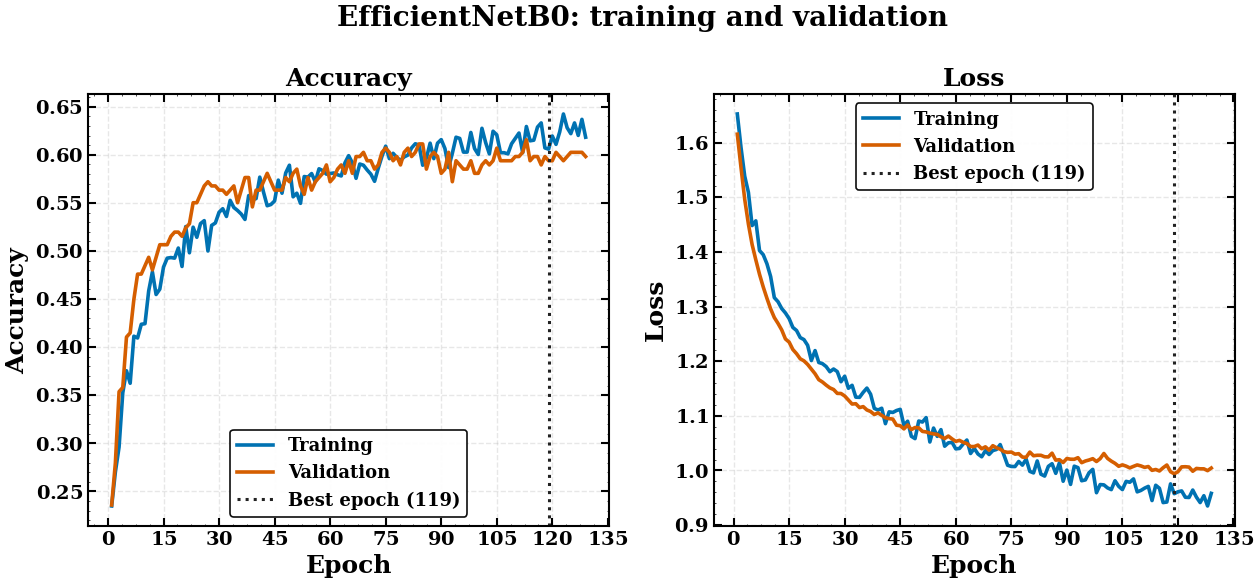

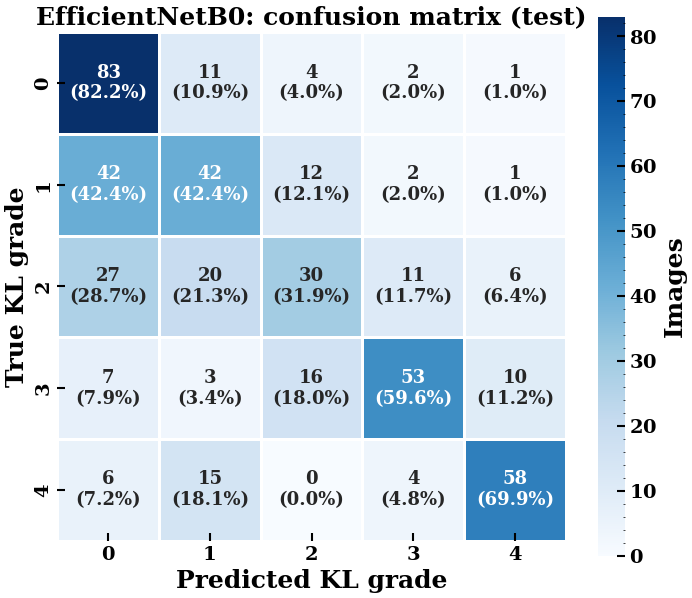

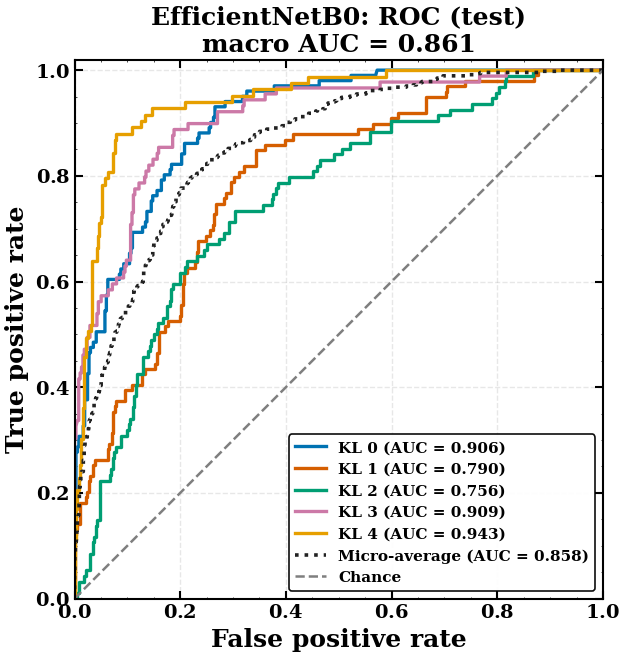


EfficientNetB0: test results (best epoch 119 of 129, early-stopped)
Test accuracy          : 0.5708   (test loss 1.0500)
Precision  weighted    : 0.5812   macro: 0.5895
Recall     weighted    : 0.5708   macro: 0.5719
F1 score   weighted    : 0.5625   macro: 0.5677
ROC AUC    macro       : 0.8607   micro: 0.8584
Val accuracy (best ep.): 0.5939   best val loss: 0.9938
Training time          : 21.4 min  (epoch 1 42 s, median epoch 9.7 s, time to best 19.8 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5030    0.8218    0.6241       101
           1     0.4615    0.4242    0.4421        99
           2     0.4839    0.3191    0.3846        94
           3     0.7361    0.5955    0.6584        89
           4     0.7632    0.6988    0.7296        83

    accuracy                         0.5708       466
   macro avg     0.5895    0.5719    0.5677       466
weighted avg     0.5812    0.5708    0.5625       466



In [14]:
run_or_load("EfficientNetB0", run_keras_model);

### 5.2 EfficientNetB1
240×240 · 1280-d features

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
32148312/32148312 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB1: input 240x240, 1280-d features -> Dense(5); params total 6,581,644, trainable 6,405
Epoch 1/300


2026-09-15 18:29:52.772839: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:52.900868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:53.276005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:53.419376: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:29:53.572326: E external/local_xla/xla/stream_

51/51 - 55s - 1s/step - accuracy: 0.2069 - loss: 1.6958 - val_accuracy: 0.2751 - val_loss: 1.5658
Epoch 2/300
51/51 - 13s - 262ms/step - accuracy: 0.2633 - loss: 1.5953 - val_accuracy: 0.3493 - val_loss: 1.5127
Epoch 3/300
51/51 - 10s - 199ms/step - accuracy: 0.3222 - loss: 1.5329 - val_accuracy: 0.3755 - val_loss: 1.4702
Epoch 4/300
51/51 - 10s - 203ms/step - accuracy: 0.3401 - loss: 1.4955 - val_accuracy: 0.4017 - val_loss: 1.4350
Epoch 5/300
51/51 - 13s - 264ms/step - accuracy: 0.3773 - loss: 1.4650 - val_accuracy: 0.4236 - val_loss: 1.4004
Epoch 6/300
51/51 - 10s - 198ms/step - accuracy: 0.4002 - loss: 1.4329 - val_accuracy: 0.4410 - val_loss: 1.3747
Epoch 7/300
51/51 - 10s - 202ms/step - accuracy: 0.4176 - loss: 1.3956 - val_accuracy: 0.4541 - val_loss: 1.3517
Epoch 8/300
51/51 - 14s - 269ms/step - accuracy: 0.4356 - loss: 1.3791 - val_accuracy: 0.4629 - val_loss: 1.3341
Epoch 9/300
51/51 - 10s - 201ms/step - accuracy: 0.4517 - loss: 1.3557 - val_accuracy: 0.4934 - val_loss: 1.307

2026-09-15 18:49:43.038611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:49:43.166989: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:49:43.300303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:49:43.574427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:49:43.727271: E external/local_xla/xla/stream_

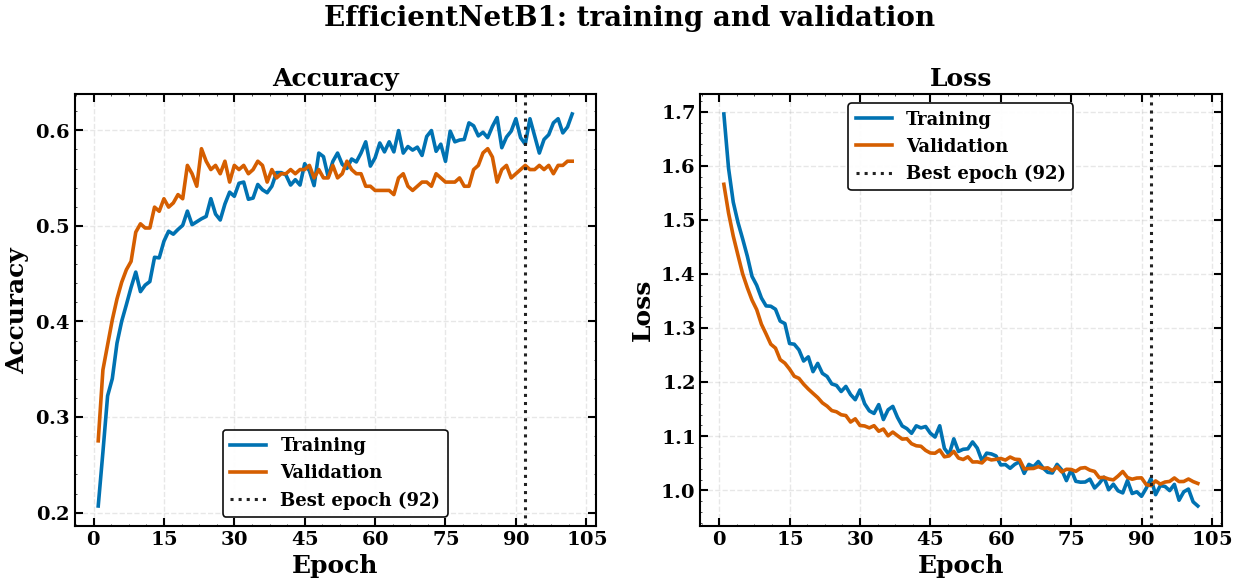

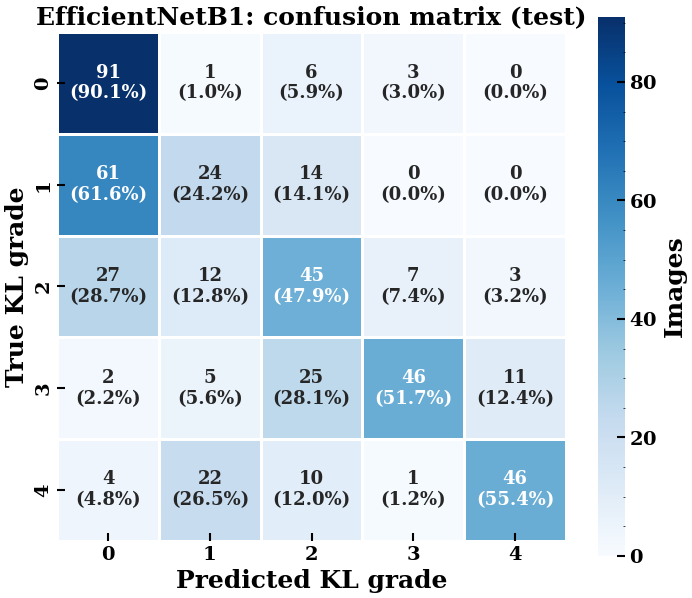

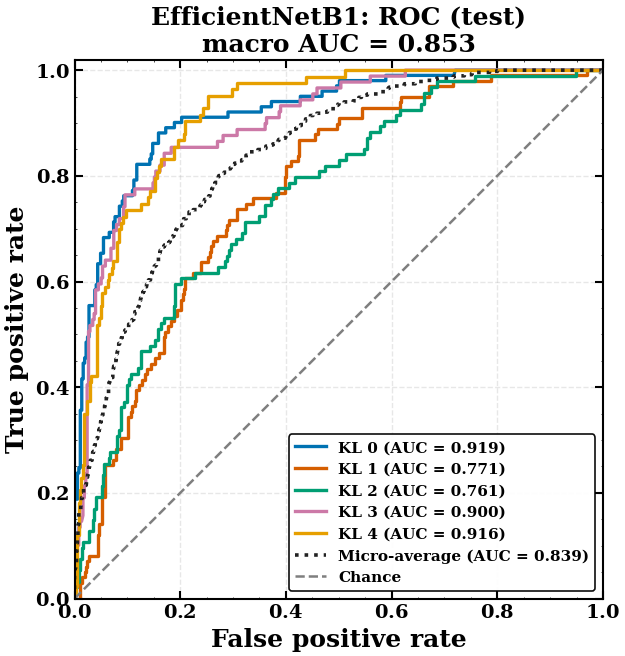


EfficientNetB1: test results (best epoch 92 of 102, early-stopped)
Test accuracy          : 0.5408   (test loss 1.1087)
Precision  weighted    : 0.5677   macro: 0.5781
Recall     weighted    : 0.5408   macro: 0.5386
F1 score   weighted    : 0.5290   macro: 0.5337
ROC AUC    macro       : 0.8534   micro: 0.8387
Val accuracy (best ep.): 0.5633   best val loss: 1.0089
Training time          : 18.5 min  (epoch 1 52 s, median epoch 10.5 s, time to best 16.8 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.4919    0.9010    0.6364       101
           1     0.3750    0.2424    0.2945        99
           2     0.4500    0.4787    0.4639        94
           3     0.8070    0.5169    0.6301        89
           4     0.7667    0.5542    0.6434        83

    accuracy                         0.5408       466
   macro avg     0.5781    0.5386    0.5337       466
weighted avg     0.5677    0.5408    0.5290       466



In [15]:
run_or_load("EfficientNetB1", run_keras_model);

### 5.3 EfficientNetB2
260×260 · 1408-d features

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
37432240/37432240 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
EfficientNetB2: input 260x260, 1408-d features -> Dense(5); params total 7,775,614, trainable 7,045
Epoch 1/300


2026-09-15 18:50:15.288916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:50:15.372499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:50:16.800566: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:50:16.903071: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 18:50:17.008789: E external/local_xla/xla/stream_

51/51 - 61s - 1s/step - accuracy: 0.2367 - loss: 1.6669 - val_accuracy: 0.3144 - val_loss: 1.5189
Epoch 2/300
51/51 - 11s - 221ms/step - accuracy: 0.2305 - loss: 1.6005 - val_accuracy: 0.3886 - val_loss: 1.4632
Epoch 3/300
51/51 - 11s - 217ms/step - accuracy: 0.2980 - loss: 1.5319 - val_accuracy: 0.4323 - val_loss: 1.4176
Epoch 4/300
51/51 - 15s - 285ms/step - accuracy: 0.3178 - loss: 1.4959 - val_accuracy: 0.4716 - val_loss: 1.3772
Epoch 5/300
51/51 - 11s - 218ms/step - accuracy: 0.3612 - loss: 1.4613 - val_accuracy: 0.5022 - val_loss: 1.3424
Epoch 6/300
51/51 - 11s - 223ms/step - accuracy: 0.3693 - loss: 1.4471 - val_accuracy: 0.5109 - val_loss: 1.3108
Epoch 7/300
51/51 - 15s - 289ms/step - accuracy: 0.4015 - loss: 1.4114 - val_accuracy: 0.5371 - val_loss: 1.2840
Epoch 8/300
51/51 - 12s - 227ms/step - accuracy: 0.4232 - loss: 1.3709 - val_accuracy: 0.5502 - val_loss: 1.2600
Epoch 9/300
51/51 - 14s - 267ms/step - accuracy: 0.4380 - loss: 1.3609 - val_accuracy: 0.5721 - val_loss: 1.239

2026-09-15 19:15:07.509944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:07.598461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:08.702071: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:08.800478: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:10.100080: E external/local_xla/xla/stream_

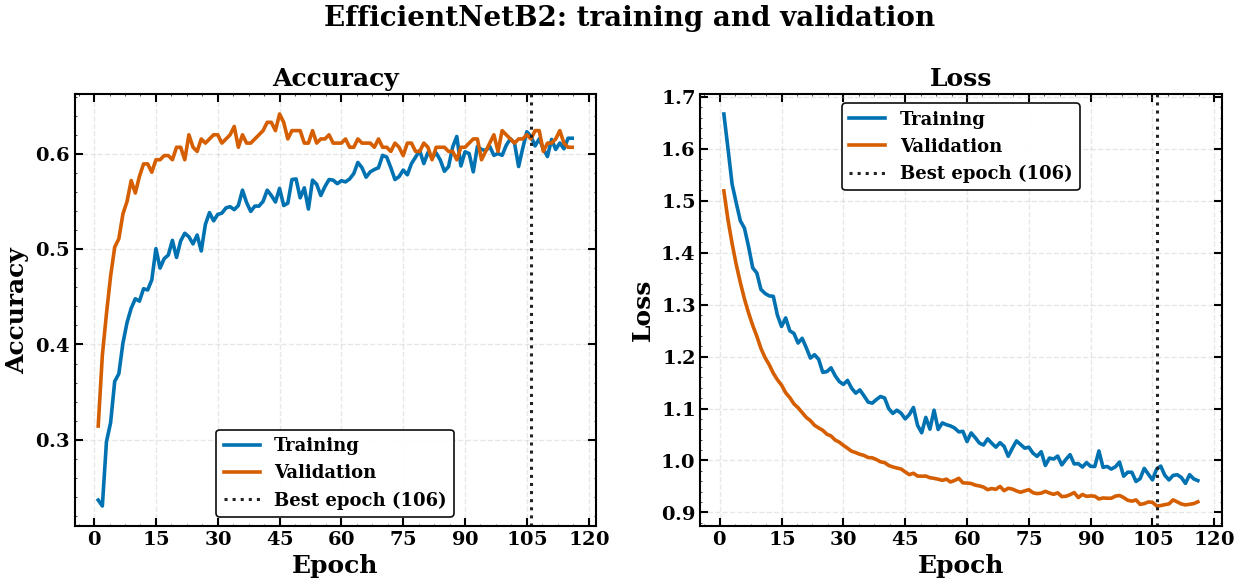

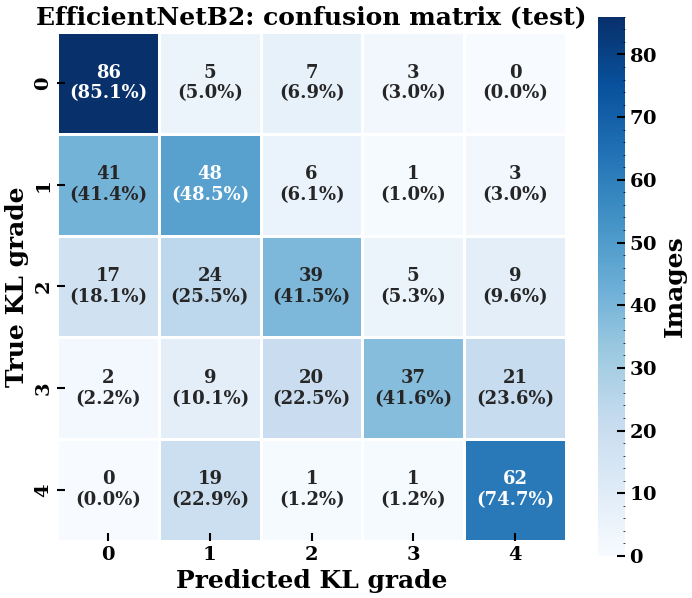

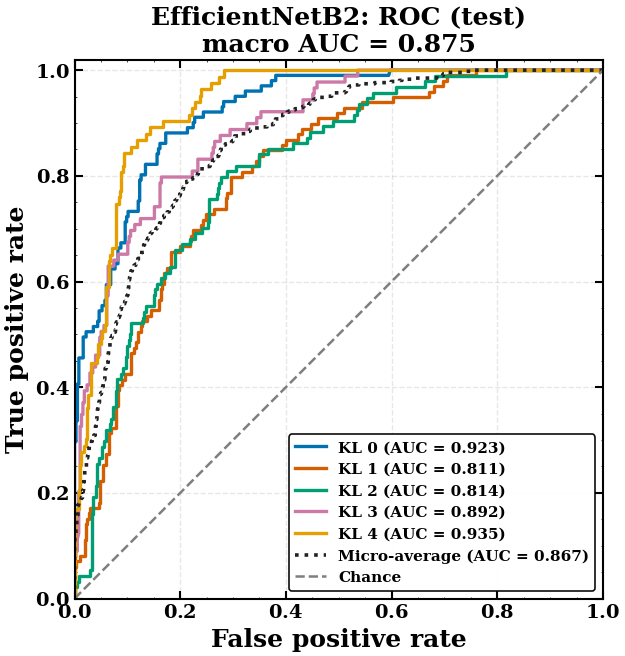


EfficientNetB2: test results (best epoch 106 of 116, early-stopped)
Test accuracy          : 0.5837   (test loss 1.0196)
Precision  weighted    : 0.5991   macro: 0.6041
Recall     weighted    : 0.5837   macro: 0.5828
F1 score   weighted    : 0.5731   macro: 0.5750
ROC AUC    macro       : 0.8750   micro: 0.8671
Val accuracy (best ep.): 0.6157   best val loss: 0.9124
Training time          : 23.0 min  (epoch 1 55 s, median epoch 11.4 s, time to best 21.1 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5890    0.8515    0.6964       101
           1     0.4571    0.4848    0.4706        99
           2     0.5342    0.4149    0.4671        94
           3     0.7872    0.4157    0.5441        89
           4     0.6526    0.7470    0.6966        83

    accuracy                         0.5837       466
   macro avg     0.6041    0.5828    0.5750       466
weighted avg     0.5991    0.5837    0.5731       466



In [16]:
run_or_load("EfficientNetB2", run_keras_model);

### 5.4 EfficientNetB3
300×300 · 1536-d features

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
50095040/50095040 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
EfficientNetB3: input 300x300, 1536-d features -> Dense(5); params total 10,791,220, trainable 7,685
Epoch 1/300


2026-09-15 19:15:45.620526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:45.712246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:47.230135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:47.344514: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:15:47.644077: E external/local_xla/xla/stream_

51/51 - 68s - 1s/step - accuracy: 0.2776 - loss: 1.6204 - val_accuracy: 0.3057 - val_loss: 1.5039
Epoch 2/300
51/51 - 14s - 278ms/step - accuracy: 0.2962 - loss: 1.5494 - val_accuracy: 0.3100 - val_loss: 1.4503
Epoch 3/300
51/51 - 14s - 275ms/step - accuracy: 0.3457 - loss: 1.4843 - val_accuracy: 0.3406 - val_loss: 1.4086
Epoch 4/300
51/51 - 16s - 322ms/step - accuracy: 0.3736 - loss: 1.4471 - val_accuracy: 0.3799 - val_loss: 1.3715
Epoch 5/300
51/51 - 14s - 269ms/step - accuracy: 0.4015 - loss: 1.4064 - val_accuracy: 0.3974 - val_loss: 1.3442
Epoch 6/300
51/51 - 17s - 331ms/step - accuracy: 0.4387 - loss: 1.3709 - val_accuracy: 0.4585 - val_loss: 1.3117
Epoch 7/300
51/51 - 14s - 272ms/step - accuracy: 0.4151 - loss: 1.3493 - val_accuracy: 0.4716 - val_loss: 1.2865
Epoch 8/300
51/51 - 17s - 331ms/step - accuracy: 0.4566 - loss: 1.3299 - val_accuracy: 0.4803 - val_loss: 1.2640
Epoch 9/300
51/51 - 14s - 273ms/step - accuracy: 0.4690 - loss: 1.2770 - val_accuracy: 0.4803 - val_loss: 1.248

2026-09-15 19:46:23.418879: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:46:23.509859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:46:23.591457: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:46:25.019237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:46:25.133415: E external/local_xla/xla/stream_

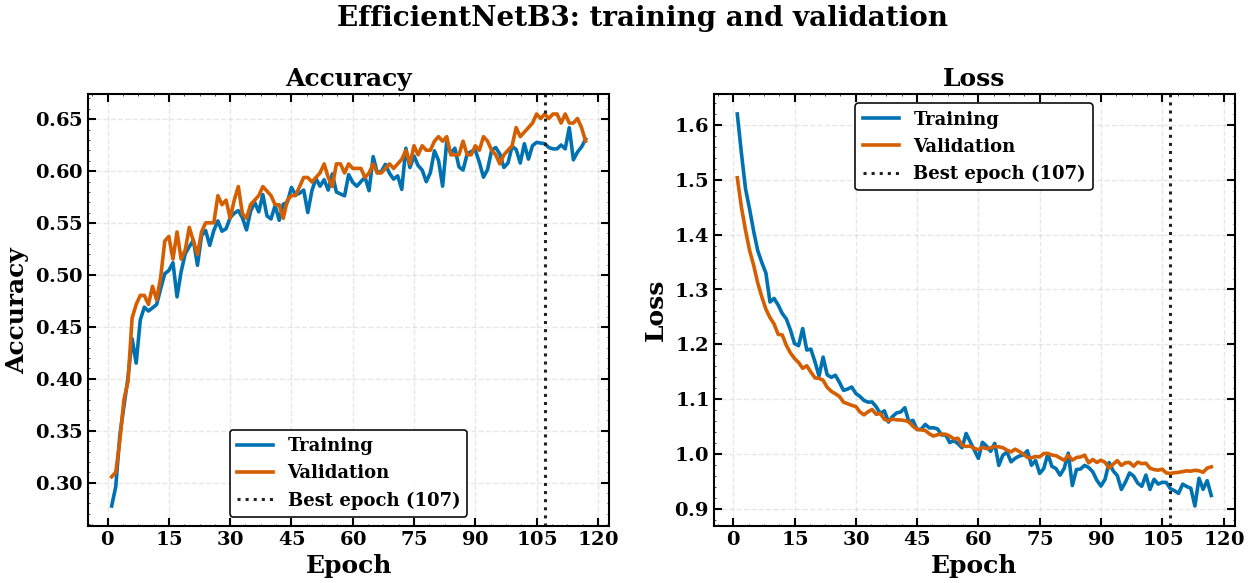

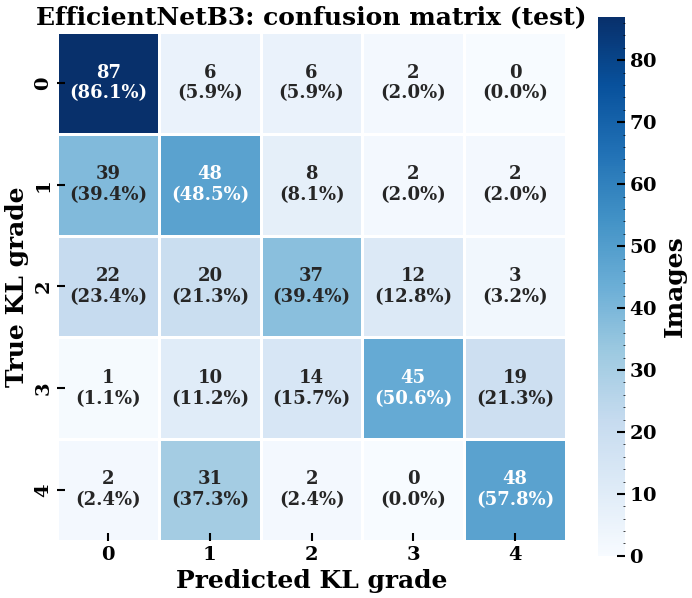

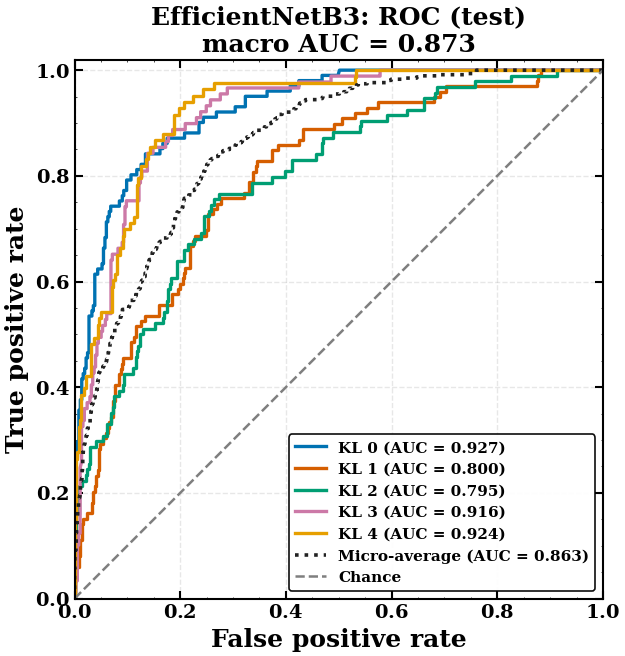


EfficientNetB3: test results (best epoch 107 of 117, early-stopped)
Test accuracy          : 0.5687   (test loss 1.0252)
Precision  weighted    : 0.5846   macro: 0.5900
Recall     weighted    : 0.5687   macro: 0.5648
F1 score   weighted    : 0.5626   macro: 0.5636
ROC AUC    macro       : 0.8725   micro: 0.8632
Val accuracy (best ep.): 0.6550   best val loss: 0.9642
Training time          : 28.1 min  (epoch 1 62 s, median epoch 13.8 s, time to best 25.7 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5762    0.8614    0.6905       101
           1     0.4174    0.4848    0.4486        99
           2     0.5522    0.3936    0.4596        94
           3     0.7377    0.5056    0.6000        89
           4     0.6667    0.5783    0.6194        83

    accuracy                         0.5687       466
   macro avg     0.5900    0.5648    0.5636       466
weighted avg     0.5846    0.5687    0.5626       466



In [17]:
run_or_load("EfficientNetB3", run_keras_model);

### 5.5 EfficientNetB4
380×380 · 1792-d features

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
78864416/78864416 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
EfficientNetB4: input 380x380, 1792-d features -> Dense(5); params total 17,682,788, trainable 8,965
Epoch 1/300


2026-09-15 19:47:08.329377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:47:08.436915: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:47:08.552813: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:47:08.667822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 19:47:08.776039: E external/local_xla/xla/stream_

51/51 - 86s - 2s/step - accuracy: 0.2305 - loss: 1.6363 - val_accuracy: 0.3493 - val_loss: 1.5405
Epoch 2/300
51/51 - 22s - 440ms/step - accuracy: 0.2893 - loss: 1.5683 - val_accuracy: 0.4279 - val_loss: 1.4807
Epoch 3/300
51/51 - 20s - 388ms/step - accuracy: 0.3185 - loss: 1.5313 - val_accuracy: 0.4803 - val_loss: 1.4278
Epoch 4/300
51/51 - 24s - 473ms/step - accuracy: 0.3513 - loss: 1.4733 - val_accuracy: 0.5240 - val_loss: 1.3871
Epoch 5/300
51/51 - 22s - 426ms/step - accuracy: 0.3934 - loss: 1.4316 - val_accuracy: 0.5502 - val_loss: 1.3501
Epoch 6/300
51/51 - 20s - 388ms/step - accuracy: 0.4170 - loss: 1.4010 - val_accuracy: 0.5459 - val_loss: 1.3219
Epoch 7/300
51/51 - 24s - 475ms/step - accuracy: 0.4374 - loss: 1.3800 - val_accuracy: 0.5590 - val_loss: 1.2966
Epoch 8/300
51/51 - 20s - 388ms/step - accuracy: 0.4343 - loss: 1.3492 - val_accuracy: 0.5633 - val_loss: 1.2740
Epoch 9/300
51/51 - 22s - 434ms/step - accuracy: 0.4888 - loss: 1.3290 - val_accuracy: 0.5677 - val_loss: 1.257

2026-09-15 20:35:33.091698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:35:33.202211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:35:33.688420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:35:33.781271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:35:34.863272: E external/local_xla/xla/stream_

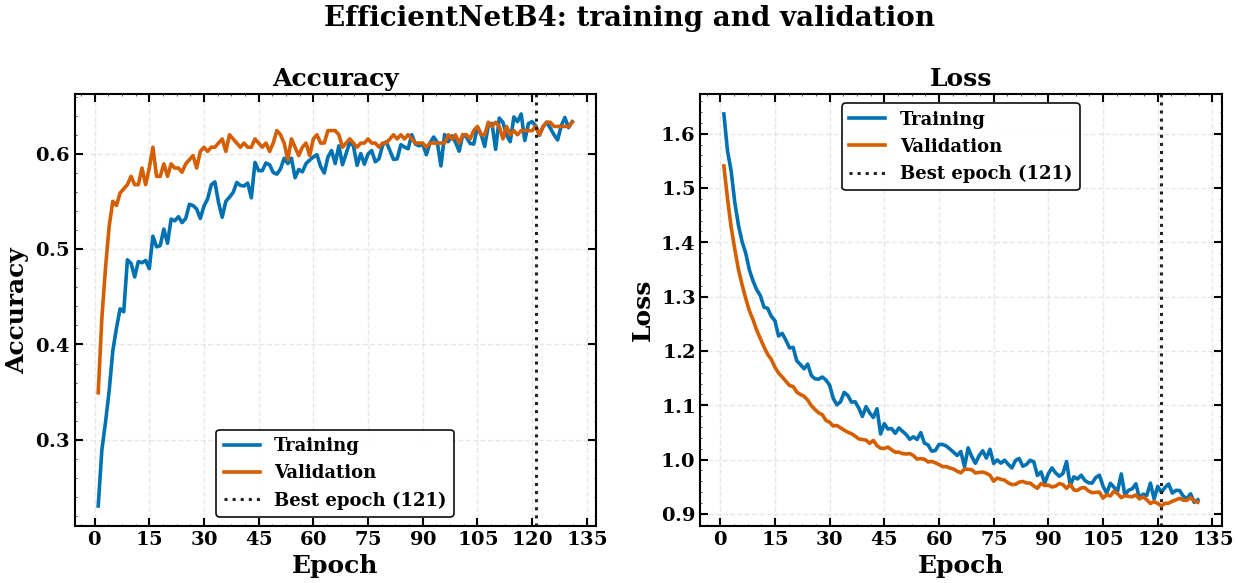

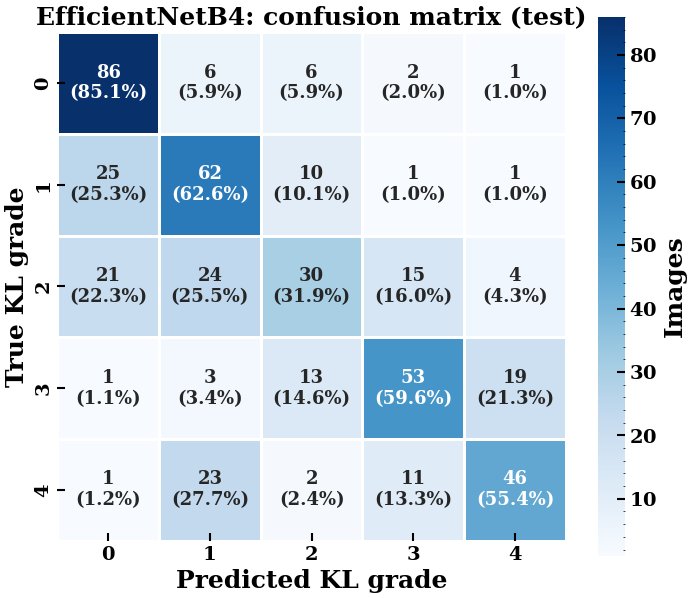

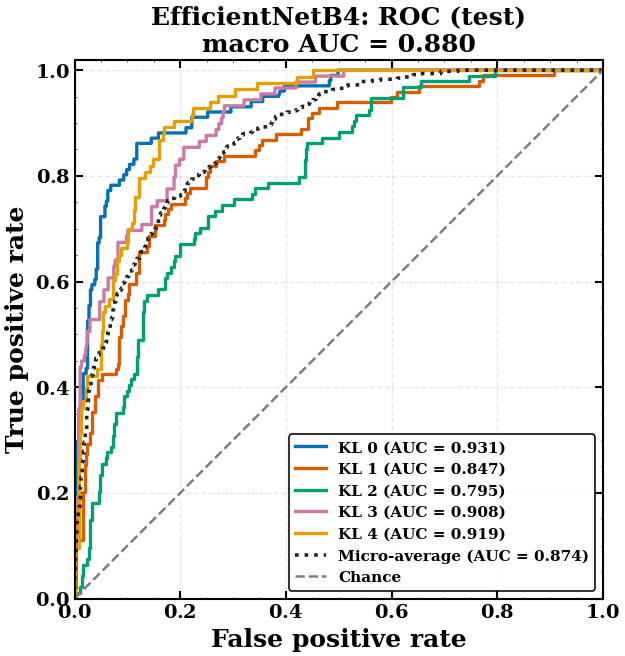


EfficientNetB4: test results (best epoch 121 of 131, early-stopped)
Test accuracy          : 0.5944   (test loss 0.9895)
Precision  weighted    : 0.5888   macro: 0.5906
Recall     weighted    : 0.5944   macro: 0.5893
F1 score   weighted    : 0.5829   macro: 0.5815
ROC AUC    macro       : 0.8799   micro: 0.8743
Val accuracy (best ep.): 0.6288   best val loss: 0.9146
Training time          : 45.2 min  (epoch 1 80 s, median epoch 20.2 s, time to best 41.8 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.6418    0.8515    0.7319       101
           1     0.5254    0.6263    0.5714        99
           2     0.4918    0.3191    0.3871        94
           3     0.6463    0.5955    0.6199        89
           4     0.6479    0.5542    0.5974        83

    accuracy                         0.5944       466
   macro avg     0.5906    0.5893    0.5815       466
weighted avg     0.5888    0.5944    0.5829       466



In [18]:
run_or_load("EfficientNetB4", run_keras_model);

### 5.6 EfficientNetB5
456×456 · 2048-d features

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
EfficientNetB5: input 456x456, 2048-d features -> Dense(5); params total 28,523,772, trainable 10,245
Epoch 1/300


2026-09-15 20:36:19.194739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:36:19.327600: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:36:19.980895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:36:20.074148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 20:36:20.176197: E external/local_xla/xla/stream_

51/51 - 109s - 2s/step - accuracy: 0.2100 - loss: 1.6347 - val_accuracy: 0.2620 - val_loss: 1.5727
Epoch 2/300
51/51 - 30s - 595ms/step - accuracy: 0.2813 - loss: 1.5613 - val_accuracy: 0.3144 - val_loss: 1.5156
Epoch 3/300
51/51 - 30s - 591ms/step - accuracy: 0.3147 - loss: 1.5196 - val_accuracy: 0.3624 - val_loss: 1.4698
Epoch 4/300
51/51 - 30s - 591ms/step - accuracy: 0.3494 - loss: 1.4728 - val_accuracy: 0.3668 - val_loss: 1.4307
Epoch 5/300
51/51 - 30s - 593ms/step - accuracy: 0.3922 - loss: 1.4237 - val_accuracy: 0.4236 - val_loss: 1.3945
Epoch 6/300
51/51 - 30s - 594ms/step - accuracy: 0.3978 - loss: 1.4217 - val_accuracy: 0.4367 - val_loss: 1.3682
Epoch 7/300
51/51 - 27s - 534ms/step - accuracy: 0.4002 - loss: 1.3954 - val_accuracy: 0.4367 - val_loss: 1.3440
Epoch 8/300
51/51 - 31s - 602ms/step - accuracy: 0.4418 - loss: 1.3632 - val_accuracy: 0.4585 - val_loss: 1.3208
Epoch 9/300
51/51 - 29s - 574ms/step - accuracy: 0.4461 - loss: 1.3463 - val_accuracy: 0.4629 - val_loss: 1.30

2026-09-15 21:25:25.833228: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 21:25:25.952512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 21:25:26.453840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 21:25:26.548022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 21:25:27.728296: E external/local_xla/xla/stream_

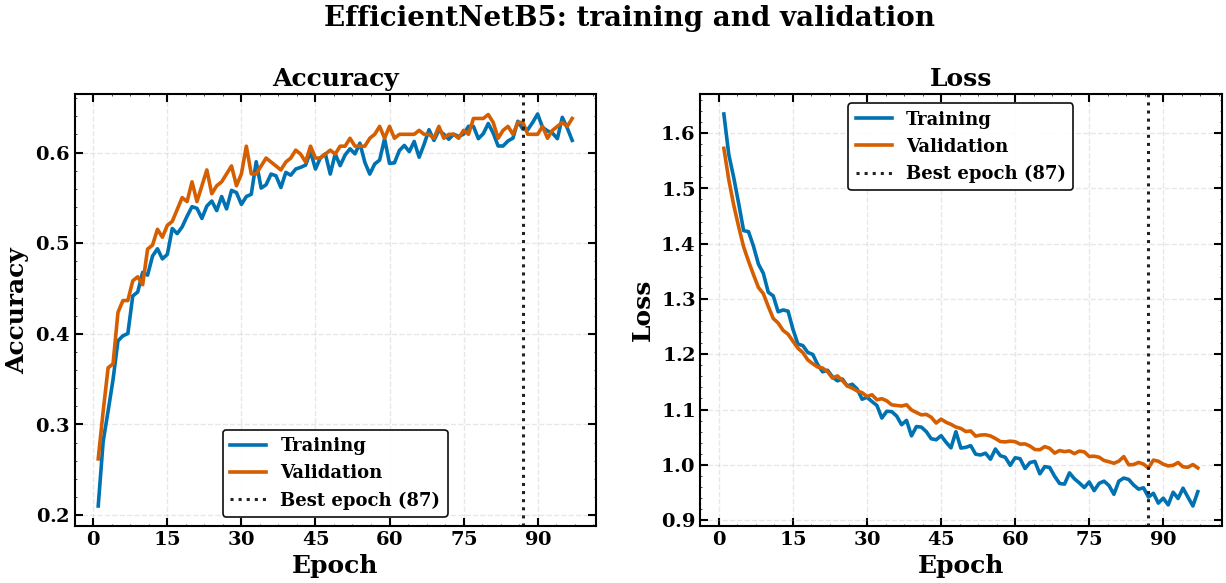

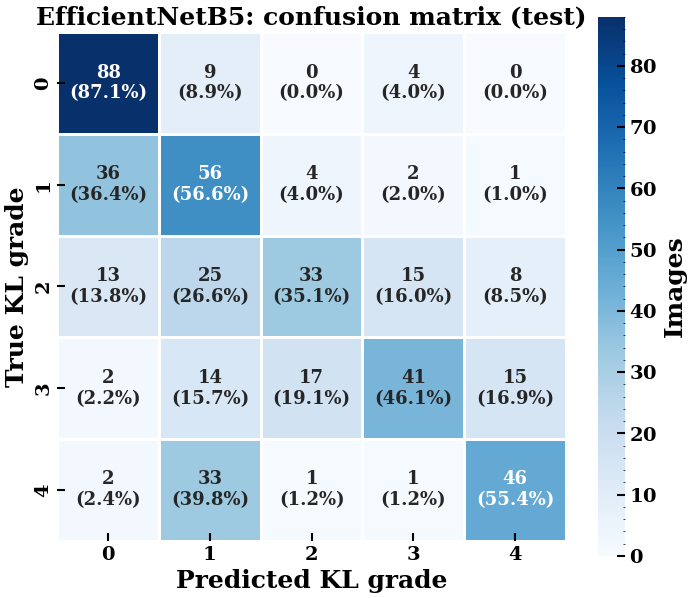

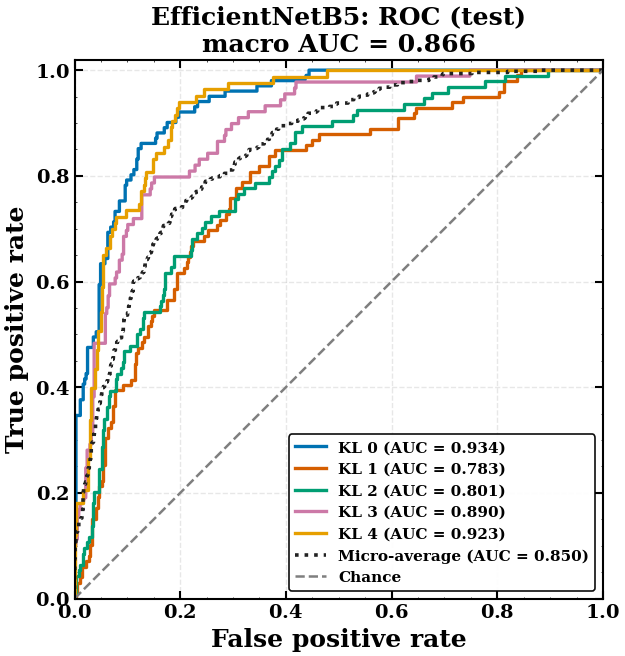


EfficientNetB5: test results (best epoch 87 of 97, early-stopped)
Test accuracy          : 0.5665   (test loss 1.0834)
Precision  weighted    : 0.5845   macro: 0.5882
Recall     weighted    : 0.5665   macro: 0.5606
F1 score   weighted    : 0.5579   macro: 0.5571
ROC AUC    macro       : 0.8661   micro: 0.8495
Val accuracy (best ep.): 0.6332   best val loss: 0.9942
Training time          : 45.7 min  (epoch 1 101 s, median epoch 27.4 s, time to best 41.1 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.6241    0.8713    0.7273       101
           1     0.4088    0.5657    0.4746        99
           2     0.6000    0.3511    0.4430        94
           3     0.6508    0.4607    0.5395        89
           4     0.6571    0.5542    0.6013        83

    accuracy                         0.5665       466
   macro avg     0.5882    0.5606    0.5571       466
weighted avg     0.5845    0.5665    0.5579       466



In [19]:
run_or_load("EfficientNetB5", run_keras_model);

### 5.6a EfficientNetB6
528×528 · 2304-d features


Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
174460376/174460376 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
EfficientNetB6: input 528x528, 2304-d features -> Dense(5); params total 40,971,668, trainable 11,525
Epoch 1/300


2026-09-16 00:59:46.360492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 00:59:46.537309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 00:59:47.329338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 00:59:47.459052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 00:59:49.946528: E external/local_xla/xla/stream_

51/51 - 130s - 3s/step - accuracy: 0.1995 - loss: 1.6340 - val_accuracy: 0.2445 - val_loss: 1.6016
Epoch 2/300
51/51 - 39s - 756ms/step - accuracy: 0.2627 - loss: 1.5809 - val_accuracy: 0.3188 - val_loss: 1.5561
Epoch 3/300
51/51 - 42s - 819ms/step - accuracy: 0.3042 - loss: 1.5372 - val_accuracy: 0.3886 - val_loss: 1.5152
Epoch 4/300
51/51 - 38s - 750ms/step - accuracy: 0.3513 - loss: 1.4992 - val_accuracy: 0.4148 - val_loss: 1.4830
Epoch 5/300
51/51 - 39s - 755ms/step - accuracy: 0.3903 - loss: 1.4691 - val_accuracy: 0.4367 - val_loss: 1.4537
Epoch 6/300
51/51 - 38s - 747ms/step - accuracy: 0.3798 - loss: 1.4523 - val_accuracy: 0.4410 - val_loss: 1.4270
Epoch 7/300
51/51 - 39s - 758ms/step - accuracy: 0.4058 - loss: 1.4293 - val_accuracy: 0.4541 - val_loss: 1.4060
Epoch 8/300
51/51 - 38s - 750ms/step - accuracy: 0.4306 - loss: 1.4062 - val_accuracy: 0.5066 - val_loss: 1.3853
Epoch 9/300
51/51 - 38s - 751ms/step - accuracy: 0.4393 - loss: 1.3920 - val_accuracy: 0.4847 - val_loss: 1.36

2026-09-16 03:04:14.444721: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 03:04:14.610531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 03:04:14.770970: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 03:04:15.369212: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 03:04:15.486225: E external/local_xla/xla/stream_

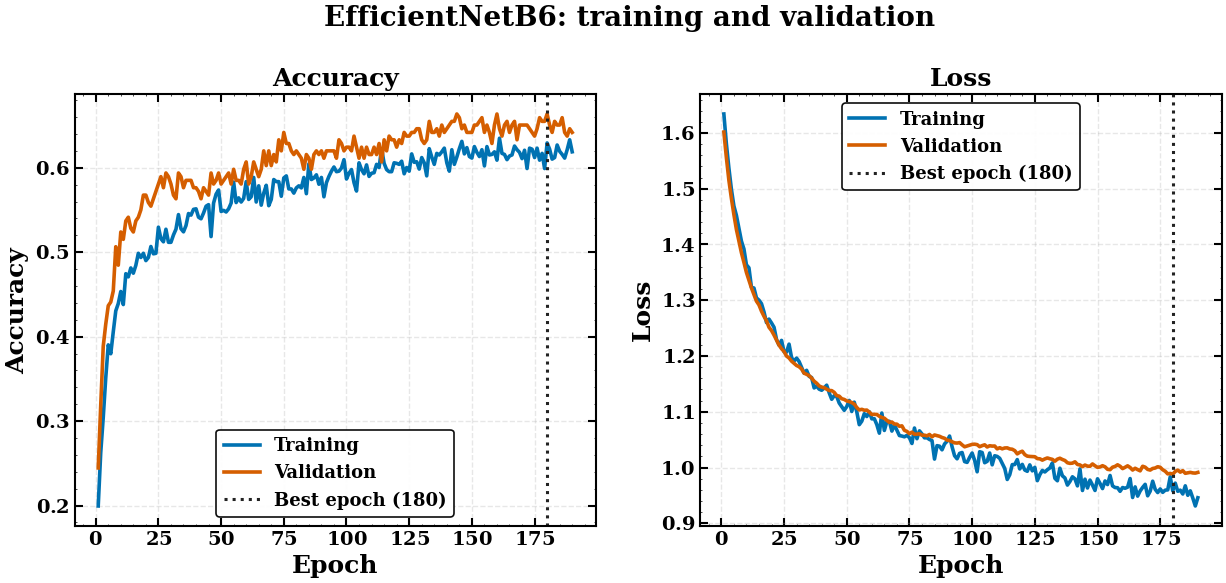

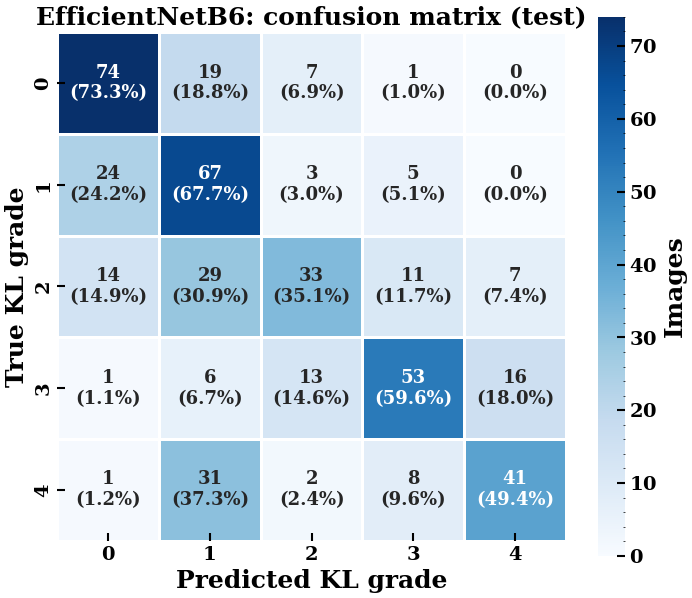

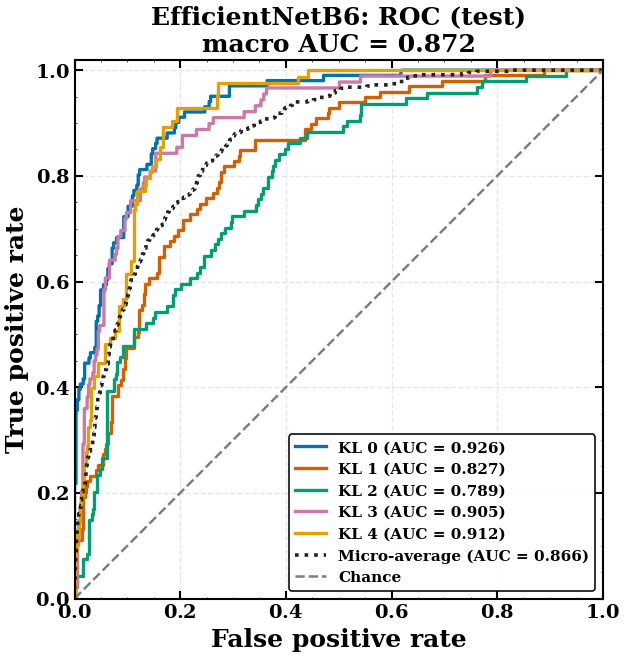


EfficientNetB6: test results (best epoch 180 of 190, early-stopped)
Test accuracy          : 0.5751   (test loss 1.0386)
Precision  weighted    : 0.5930   macro: 0.5958
Recall     weighted    : 0.5751   macro: 0.5700
F1 score   weighted    : 0.5708   macro: 0.5698
ROC AUC    macro       : 0.8718   micro: 0.8662
Val accuracy (best ep.): 0.6638   best val loss: 0.9880
Training time          : 114.0 min  (epoch 1 121 s, median epoch 35.4 s, time to best 108.1 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.6491    0.7327    0.6884       101
           1     0.4408    0.6768    0.5339        99
           2     0.5690    0.3511    0.4342        94
           3     0.6795    0.5955    0.6347        89
           4     0.6406    0.4940    0.5578        83

    accuracy                         0.5751       466
   macro avg     0.5958    0.5700    0.5698       466
weighted avg     0.5930    0.5751    0.5708       466



In [29]:
run_or_load("EfficientNetB6", run_keras_model);


### 5.6b EfficientNetB7
600×600 · 2560-d features


Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
EfficientNetB7: input 600x600, 2560-d features -> Dense(5); params total 64,110,492, trainable 12,805
Epoch 1/300


2026-09-17 00:20:20.872797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 00:20:21.070652: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 00:20:22.019716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 00:20:22.157102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 00:20:24.662991: E external/local_xla/xla/stream_

51/51 - 151s - 3s/step - accuracy: 0.2138 - loss: 1.6430 - val_accuracy: 0.2489 - val_loss: 1.5808
Epoch 2/300
51/51 - 48s - 948ms/step - accuracy: 0.2714 - loss: 1.5654 - val_accuracy: 0.3930 - val_loss: 1.5222
Epoch 3/300
51/51 - 52s - 1s/step - accuracy: 0.2912 - loss: 1.5373 - val_accuracy: 0.4541 - val_loss: 1.4786
Epoch 4/300
51/51 - 49s - 953ms/step - accuracy: 0.3377 - loss: 1.4828 - val_accuracy: 0.4803 - val_loss: 1.4410
Epoch 5/300
51/51 - 52s - 1s/step - accuracy: 0.3724 - loss: 1.4567 - val_accuracy: 0.5022 - val_loss: 1.4077
Epoch 6/300
51/51 - 50s - 981ms/step - accuracy: 0.3649 - loss: 1.4424 - val_accuracy: 0.5109 - val_loss: 1.3854
Epoch 7/300
51/51 - 50s - 973ms/step - accuracy: 0.4015 - loss: 1.4026 - val_accuracy: 0.5197 - val_loss: 1.3620
Epoch 8/300
51/51 - 52s - 1s/step - accuracy: 0.4170 - loss: 1.3906 - val_accuracy: 0.5284 - val_loss: 1.3418
Epoch 9/300
51/51 - 49s - 954ms/step - accuracy: 0.4387 - loss: 1.3628 - val_accuracy: 0.5371 - val_loss: 1.3244
Epoch 

2026-09-17 02:06:20.288697: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 02:06:20.482802: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 02:06:20.673495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 02:06:21.397233: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 02:06:21.536620: E external/local_xla/xla/stream_

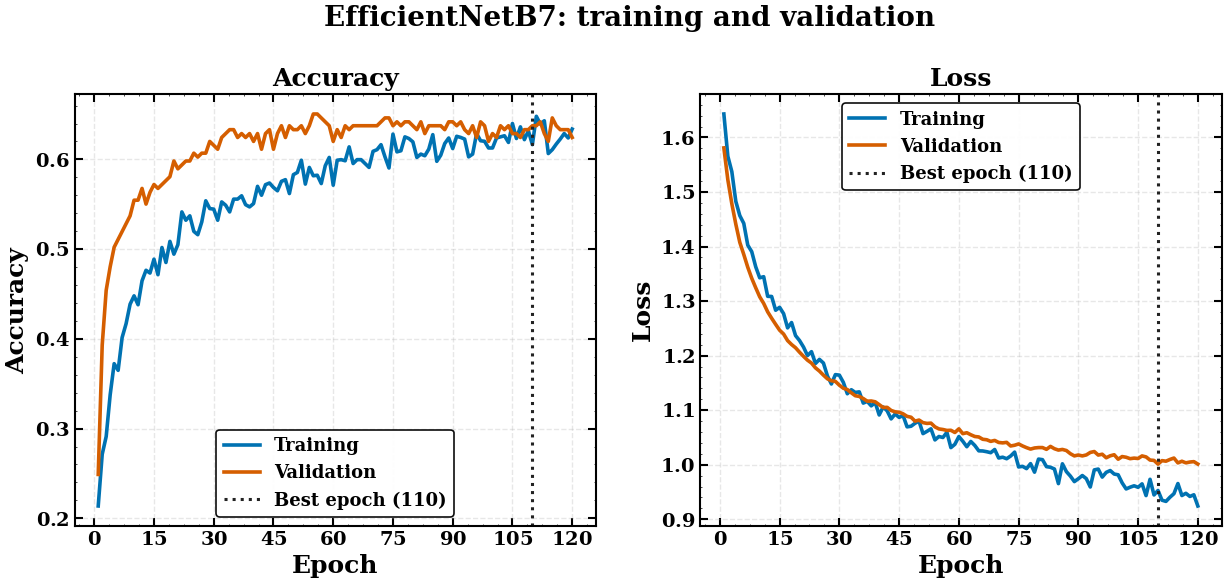

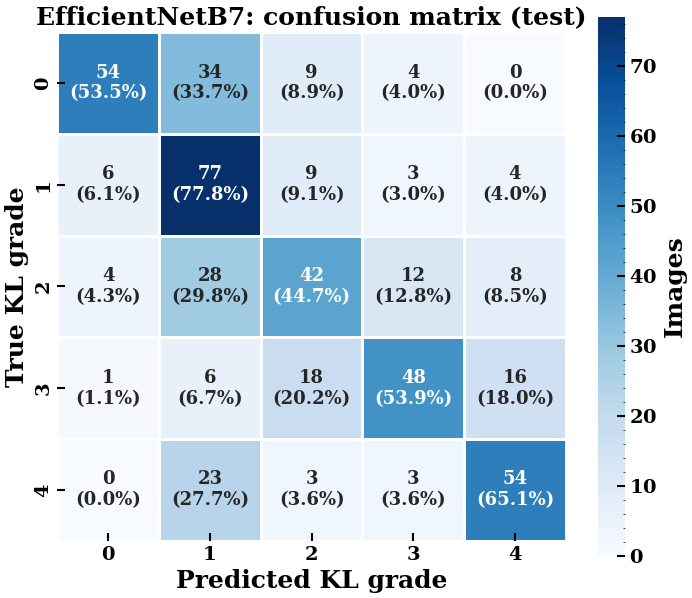

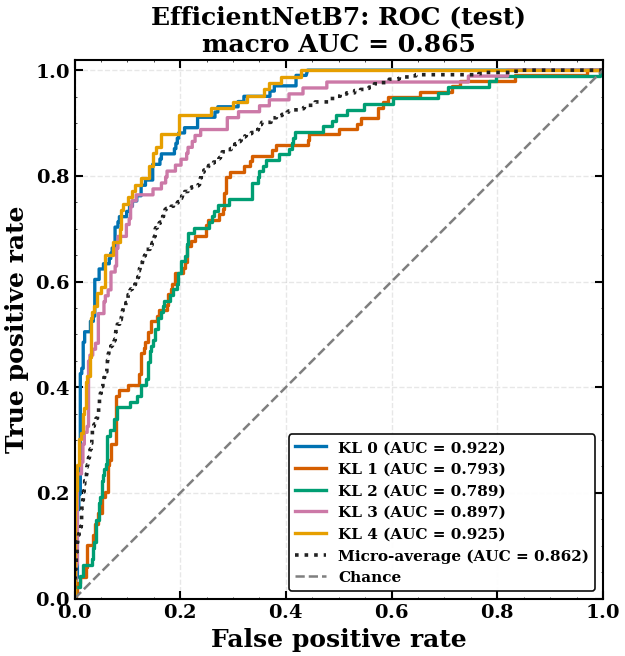


EfficientNetB7: test results (best epoch 110 of 120, early-stopped)
Test accuracy          : 0.5901   (test loss 1.0642)
Precision  weighted    : 0.6303   macro: 0.6304
Recall     weighted    : 0.5901   macro: 0.5898
F1 score   weighted    : 0.5923   macro: 0.5931
ROC AUC    macro       : 0.8652   micro: 0.8619
Val accuracy (best ep.): 0.6376   best val loss: 1.0011
Training time          : 96.4 min  (epoch 1 140 s, median epoch 45.0 s, time to best 87.4 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.8308    0.5347    0.6506       101
           1     0.4583    0.7778    0.5768        99
           2     0.5185    0.4468    0.4800        94
           3     0.6857    0.5393    0.6038        89
           4     0.6585    0.6506    0.6545        83

    accuracy                         0.5901       466
   macro avg     0.6304    0.5898    0.5931       466
weighted avg     0.6303    0.5901    0.5923       466



In [14]:
run_or_load("EfficientNetB7", run_keras_model);


### 5.7 ResNet50
224×224 · 2048-d features · caffe preprocessing

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
ResNet50: input 224x224, 2048-d features -> Dense(5); params total 23,597,957, trainable 10,245
Epoch 1/300
51/51 - 22s - 430ms/step - accuracy: 0.2212 - loss: 1.8426 - val_accuracy: 0.3231 - val_loss: 1.5518
Epoch 2/300
51/51 - 10s - 196ms/step - accuracy: 0.3147 - loss: 1.5832 - val_accuracy: 0.4061 - val_loss: 1.3967
Epoch 3/300
51/51 - 10s - 195ms/step - accuracy: 0.3730 - loss: 1.4822 - val_accuracy: 0.4323 - val_loss: 1.2990
Epoch 4/300
51/51 - 13s - 252ms/step - accuracy: 0.4033 - loss: 1.3934 - val_accuracy: 0.4017 - val_loss: 1.2625
Epoch 5/300
51/51 - 10s - 193ms/step - accuracy: 0.4430 - loss: 1.3251 - val_accuracy: 0.5066 - val_loss: 1.1885
Epoch 6/300
51/51 - 10s - 191ms/step - accuracy: 0.4709 - loss: 1.2941 - val_accuracy: 0.4803 - val_loss: 1.1811
Epoch 7/300
51/51 - 13s - 249ms/step - accuracy: 0.4746 - loss: 1.2557 - val_accuracy: 0.5153 - val_lo

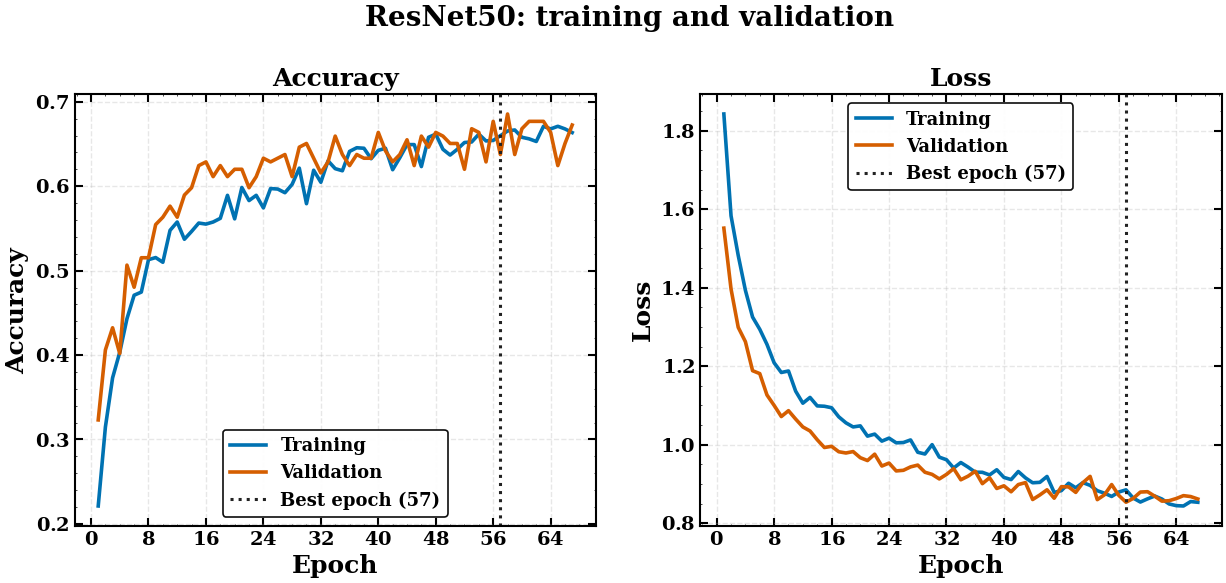

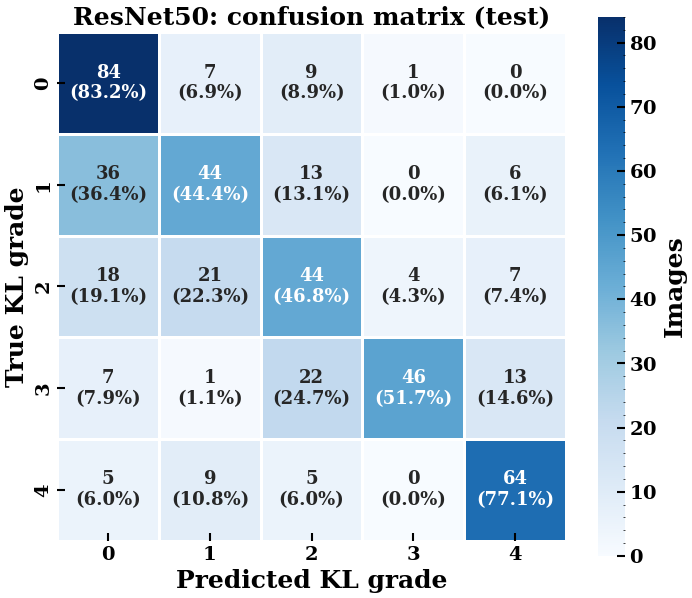

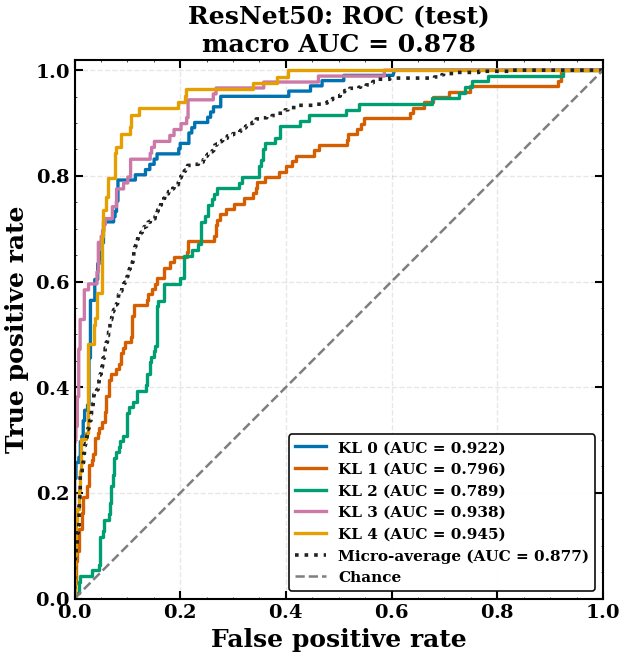


ResNet50: test results (best epoch 57 of 67, early-stopped)
Test accuracy          : 0.6052   (test loss 0.9821)
Precision  weighted    : 0.6297   macro: 0.6366
Recall     weighted    : 0.6052   macro: 0.6064
F1 score   weighted    : 0.6006   macro: 0.6046
ROC AUC    macro       : 0.8781   micro: 0.8766
Val accuracy (best ep.): 0.6376   best val loss: 0.8534
Training time          : 11.1 min  (epoch 1 19 s, median epoch 9.8 s, time to best 9.5 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5600    0.8317    0.6693       101
           1     0.5366    0.4444    0.4862        99
           2     0.4731    0.4681    0.4706        94
           3     0.9020    0.5169    0.6571        89
           4     0.7111    0.7711    0.7399        83

    accuracy                         0.6052       466
   macro avg     0.6366    0.6064    0.6046       466
weighted avg     0.6297    0.6052    0.6006       466



In [20]:
run_or_load("ResNet50", run_keras_model);

### 5.8 ResNet101
224×224 · 2048-d features · caffe preprocessing

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
ResNet101: input 224x224, 2048-d features -> Dense(5); params total 42,668,421, trainable 10,245
Epoch 1/300
51/51 - 25s - 482ms/step - accuracy: 0.2057 - loss: 2.0522 - val_accuracy: 0.2445 - val_loss: 1.6984
Epoch 2/300
51/51 - 10s - 198ms/step - accuracy: 0.2862 - loss: 1.6226 - val_accuracy: 0.3319 - val_loss: 1.4856
Epoch 3/300
51/51 - 13s - 255ms/step - accuracy: 0.3488 - loss: 1.4792 - val_accuracy: 0.4061 - val_loss: 1.3585
Epoch 4/300
51/51 - 10s - 194ms/step - accuracy: 0.3916 - loss: 1.4007 - val_accuracy: 0.4236 - val_loss: 1.2898
Epoch 5/300
51/51 - 10s - 191ms/step - accuracy: 0.4418 - loss: 1.3249 - val_accuracy: 0.4585 - val_loss: 1.2412
Epoch 6/300
51/51 - 13s - 256ms/step - accuracy: 0.4572 - loss: 1.2847 - val_accuracy: 0.4629 - val_loss: 1.2112
Epoch 7/300
51/51 - 10s - 190ms/step - accuracy: 0.4765 - loss: 1.2314 - val_accuracy: 0.4934 - val_l

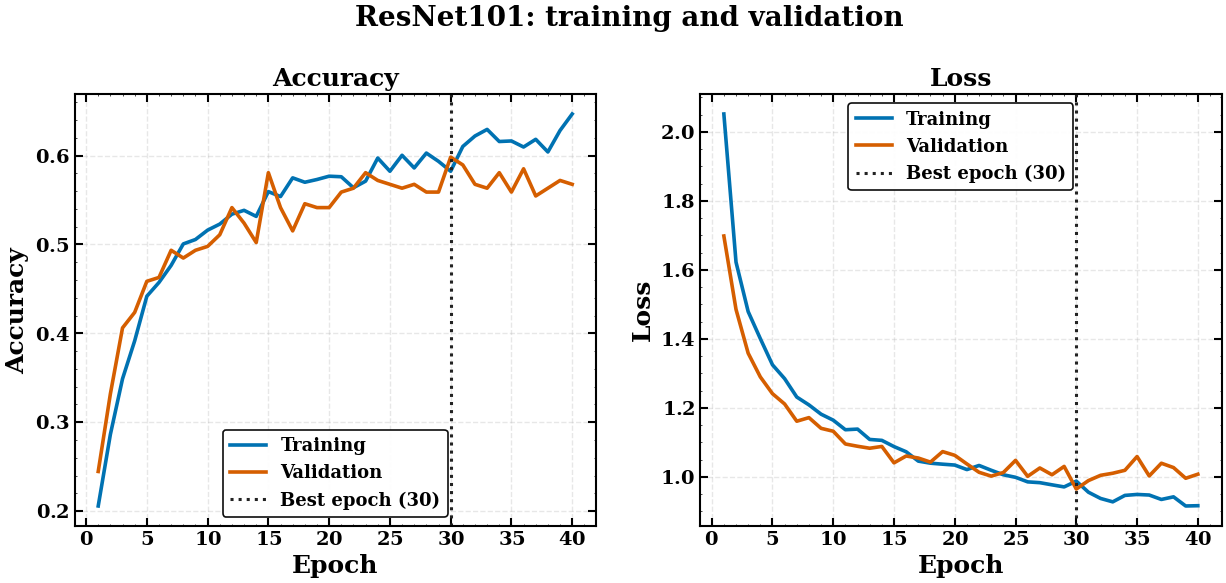

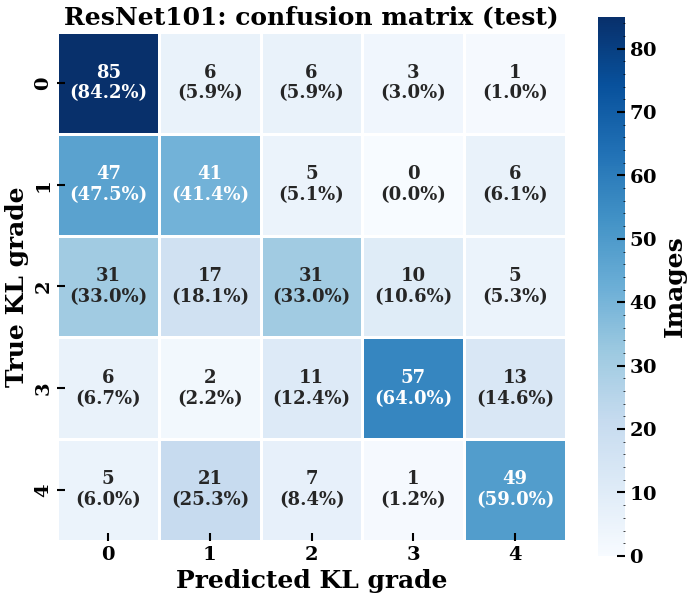

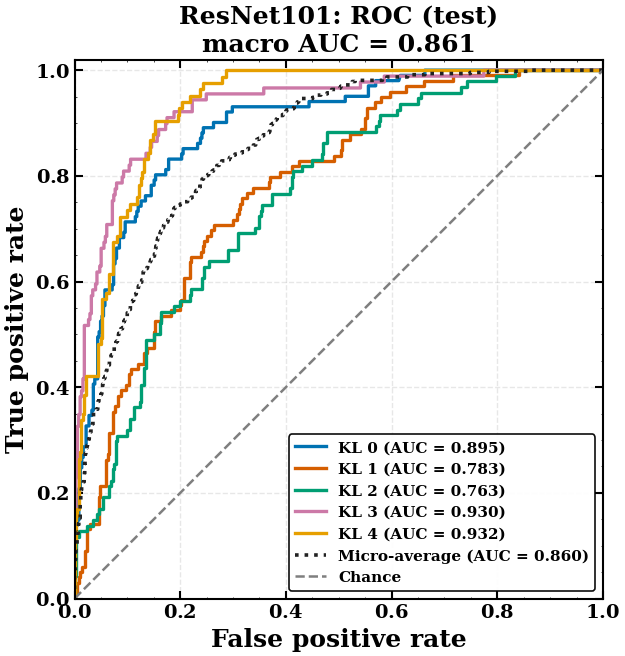


ResNet101: test results (best epoch 30 of 40, early-stopped)
Test accuracy          : 0.5644   (test loss 1.0336)
Precision  weighted    : 0.5815   macro: 0.5883
Recall     weighted    : 0.5644   macro: 0.5633
F1 score   weighted    : 0.5561   macro: 0.5597
ROC AUC    macro       : 0.8606   micro: 0.8599
Val accuracy (best ep.): 0.5983   best val loss: 0.9647
Training time          : 6.8 min  (epoch 1 22 s, median epoch 9.9 s, time to best 5.2 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.4885    0.8416    0.6182       101
           1     0.4713    0.4141    0.4409        99
           2     0.5167    0.3298    0.4026        94
           3     0.8028    0.6404    0.7125        89
           4     0.6622    0.5904    0.6242        83

    accuracy                         0.5644       466
   macro avg     0.5883    0.5633    0.5597       466
weighted avg     0.5815    0.5644    0.5561       466



In [21]:
run_or_load("ResNet101", run_keras_model);

### 5.9 DenseNet121
224×224 · 1024-d features · torch preprocessing

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
DenseNet121: input 224x224, 1024-d features -> Dense(5); params total 7,042,629, trainable 5,125
Epoch 1/300
51/51 - 37s - 731ms/step - accuracy: 0.2082 - loss: 2.1194 - val_accuracy: 0.2358 - val_loss: 1.7689
Epoch 2/300
51/51 - 10s - 192ms/step - accuracy: 0.2206 - loss: 1.7080 - val_accuracy: 0.2533 - val_loss: 1.6469
Epoch 3/300
51/51 - 10s - 199ms/step - accuracy: 0.2392 - loss: 1.6654 - val_accuracy: 0.2969 - val_loss: 1.5903
Epoch 4/300
51/51 - 13s - 253ms/step - accuracy: 0.2515 - loss: 1.6062 - val_accuracy: 0.3144 - val_loss: 1.5633
Epoch 5/300
51/51 - 10s - 192ms/step - accuracy: 0.2856 - loss: 1.5749 - val_accuracy: 0.3231 - val_loss: 1.5019
Epoch 6/300
51/51 - 10s - 189ms/step - accuracy: 0.3178 - loss: 1.5273 - val_accuracy: 0.3231 - val_loss: 1.5090
Epoch 7/300
51/51 - 13s - 252ms/step - accuracy: 0.3445 - loss: 1.4894 - val_accuracy: 0.3581 - val_l

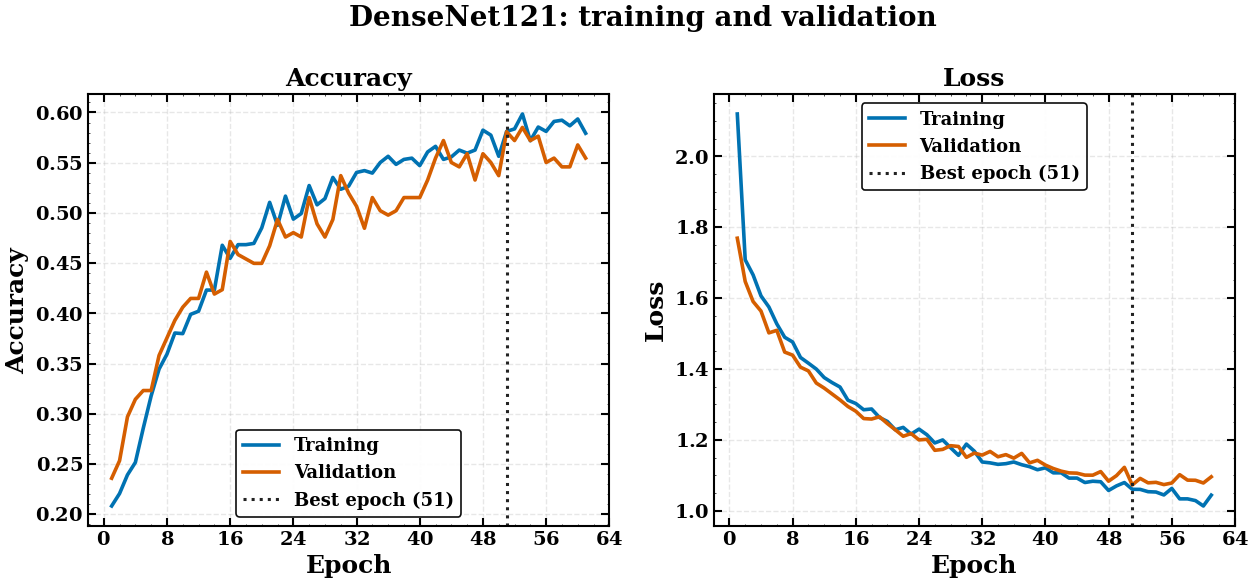

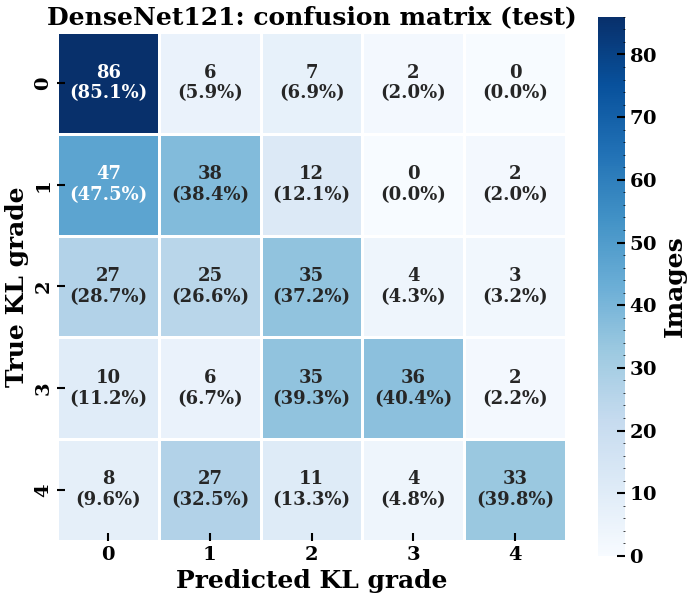

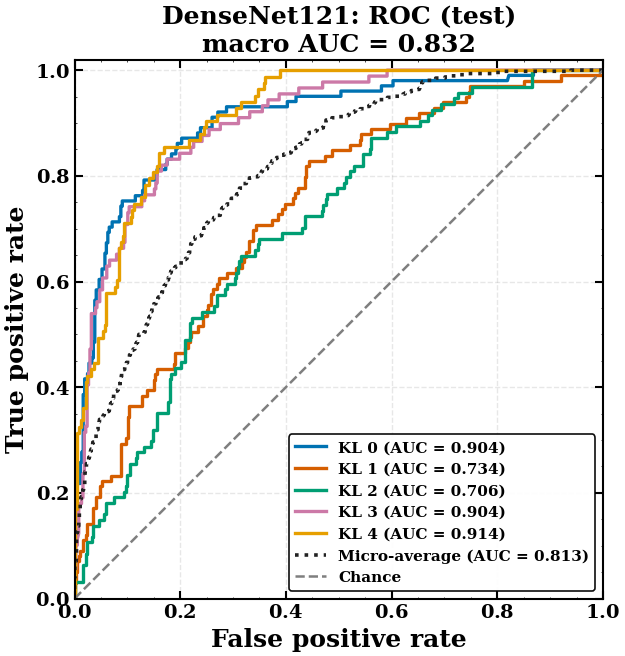


DenseNet121: test results (best epoch 51 of 61, early-stopped)
Test accuracy          : 0.4893   (test loss 1.1795)
Precision  weighted    : 0.5509   macro: 0.5627
Recall     weighted    : 0.4893   macro: 0.4819
F1 score   weighted    : 0.4842   macro: 0.4851
ROC AUC    macro       : 0.8324   micro: 0.8132
Val accuracy (best ep.): 0.5808   best val loss: 1.0728
Training time          : 10.5 min  (epoch 1 34 s, median epoch 9.9 s, time to best 8.8 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.4831    0.8515    0.6165       101
           1     0.3725    0.3838    0.3781        99
           2     0.3500    0.3723    0.3608        94
           3     0.7826    0.4045    0.5333        89
           4     0.8250    0.3976    0.5366        83

    accuracy                         0.4893       466
   macro avg     0.5627    0.4819    0.4851       466
weighted avg     0.5509    0.4893    0.4842       466



In [22]:
run_or_load("DenseNet121", run_keras_model);

### 5.10 DenseNet201
224×224 · 1920-d features · torch preprocessing

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
DenseNet201: input 224x224, 1920-d features -> Dense(5); params total 18,331,589, trainable 9,605
Epoch 1/300
51/51 - 56s - 1s/step - accuracy: 0.2057 - loss: 1.7812 - val_accuracy: 0.2533 - val_loss: 1.7174
Epoch 2/300
51/51 - 10s - 201ms/step - accuracy: 0.2546 - loss: 1.6295 - val_accuracy: 0.2926 - val_loss: 1.6317
Epoch 3/300
51/51 - 13s - 250ms/step - accuracy: 0.3129 - loss: 1.5483 - val_accuracy: 0.2969 - val_loss: 1.5763
Epoch 4/300
51/51 - 10s - 198ms/step - accuracy: 0.3395 - loss: 1.5013 - val_accuracy: 0.3668 - val_loss: 1.4997
Epoch 5/300
51/51 - 10s - 194ms/step - accuracy: 0.3965 - loss: 1.4399 - val_accuracy: 0.3668 - val_loss: 1.4628
Epoch 6/300
51/51 - 13s - 254ms/step - accuracy: 0.4120 - loss: 1.4049 - val_accuracy: 0.3712 - val_loss: 1.4472
Epoch 7/300
51/51 - 10s - 206ms/step - accuracy: 0.

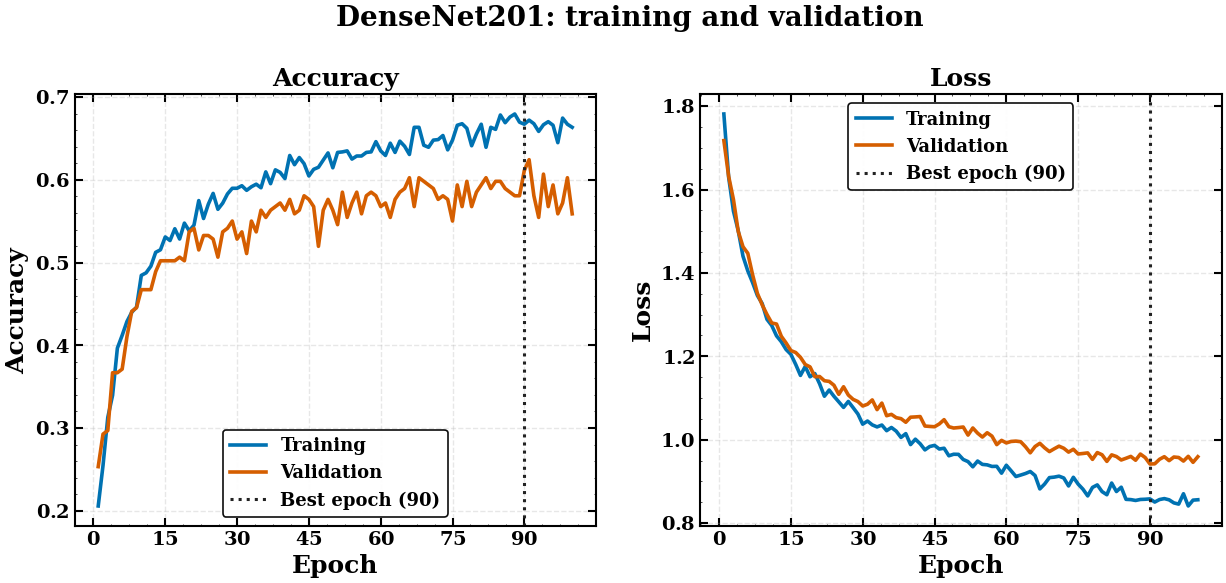

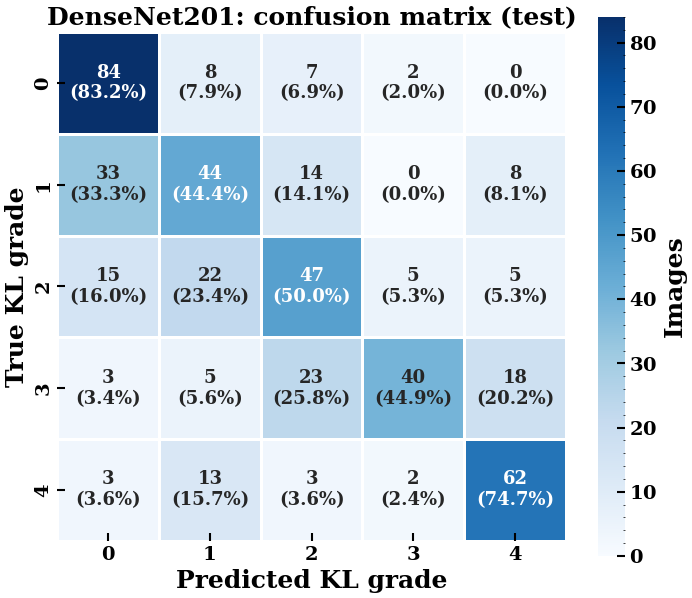

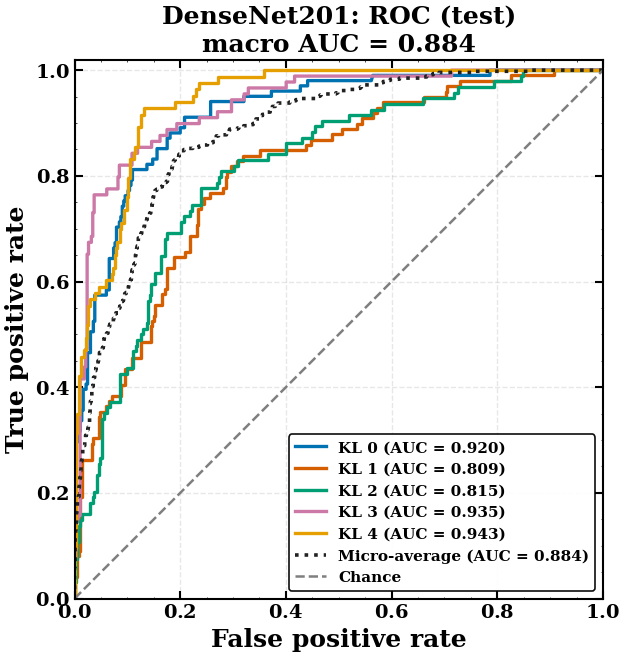


DenseNet201: test results (best epoch 90 of 100, early-stopped)
Test accuracy          : 0.5944   (test loss 0.9566)
Precision  weighted    : 0.6090   macro: 0.6140
Recall     weighted    : 0.5944   macro: 0.5945
F1 score   weighted    : 0.5873   macro: 0.5896
ROC AUC    macro       : 0.8844   micro: 0.8839
Val accuracy (best ep.): 0.6114   best val loss: 0.9417
Training time          : 17.5 min  (epoch 1 50 s, median epoch 10.1 s, time to best 15.8 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.6087    0.8317    0.7029       101
           1     0.4783    0.4444    0.4607        99
           2     0.5000    0.5000    0.5000        94
           3     0.8163    0.4494    0.5797        89
           4     0.6667    0.7470    0.7045        83

    accuracy                         0.5944       466
   macro avg     0.6140    0.5945    0.5896       466
weighted avg     0.6090    0.5944    0.5873       466



In [23]:
run_or_load("DenseNet201", run_keras_model);

### 5.11 InceptionV3
299×299 · 2048-d features · tf preprocessing ([-1, 1])

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
InceptionV3: input 299x299, 2048-d features -> Dense(5); params total 21,813,029, trainable 10,245
Epoch 1/300


2026-09-15 22:18:08.392686: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv (f32[32,160,17,17]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,160,17,17]{3,2,1,0}, f32[160,160,1,7]{3,2,1,0}), window={size=1x7 pad=0_0x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-15 22:18:08.392769: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.971643025s
Trying algorithm eng28{k2=3,k3=0} for conv (f32[32,160,17,17]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,160,17,17]{3,2,1,0}, f32[160,160,1,7]{3,2,1,0}), window={size=1x7 pad=0_0x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"oper

51/51 - 31s - 616ms/step - accuracy: 0.1902 - loss: 1.6784 - val_accuracy: 0.2707 - val_loss: 1.6088
Epoch 2/300
51/51 - 17s - 333ms/step - accuracy: 0.2677 - loss: 1.5679 - val_accuracy: 0.3188 - val_loss: 1.5208
Epoch 3/300
51/51 - 14s - 271ms/step - accuracy: 0.3470 - loss: 1.4911 - val_accuracy: 0.3974 - val_loss: 1.4434
Epoch 4/300
51/51 - 17s - 331ms/step - accuracy: 0.3928 - loss: 1.4401 - val_accuracy: 0.4454 - val_loss: 1.3982
Epoch 5/300
51/51 - 14s - 270ms/step - accuracy: 0.4244 - loss: 1.3939 - val_accuracy: 0.4934 - val_loss: 1.3430
Epoch 6/300
51/51 - 14s - 268ms/step - accuracy: 0.4542 - loss: 1.3535 - val_accuracy: 0.4891 - val_loss: 1.3273
Epoch 7/300
51/51 - 17s - 330ms/step - accuracy: 0.4839 - loss: 1.3188 - val_accuracy: 0.4934 - val_loss: 1.2804
Epoch 8/300
51/51 - 14s - 272ms/step - accuracy: 0.4758 - loss: 1.3010 - val_accuracy: 0.4760 - val_loss: 1.2718
Epoch 9/300
51/51 - 17s - 332ms/step - accuracy: 0.4901 - loss: 1.2797 - val_accuracy: 0.5328 - val_loss: 1.

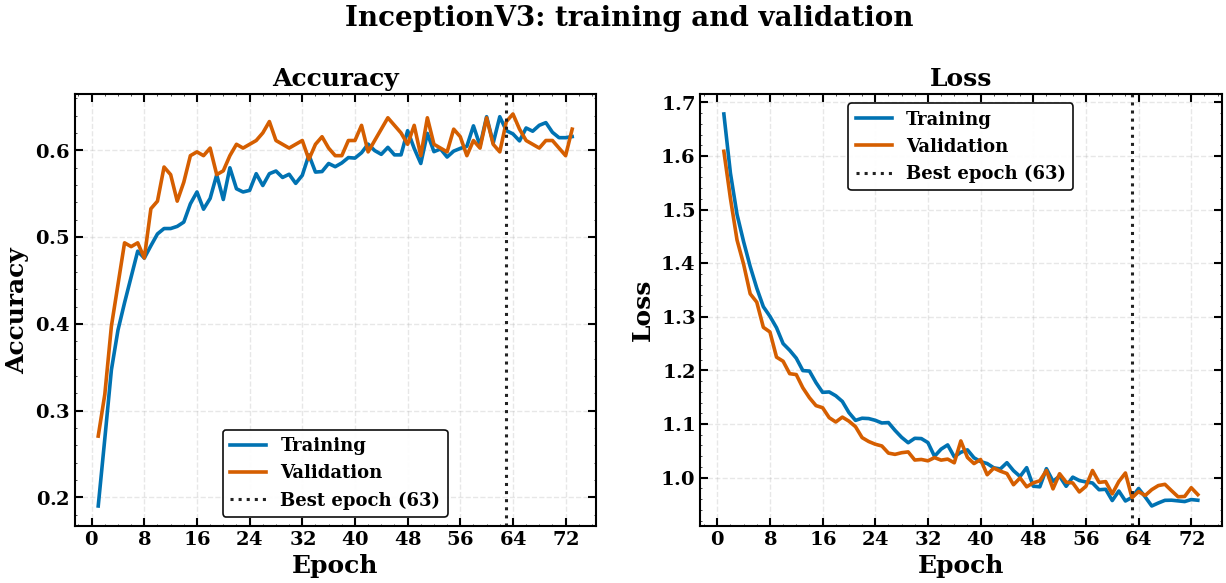

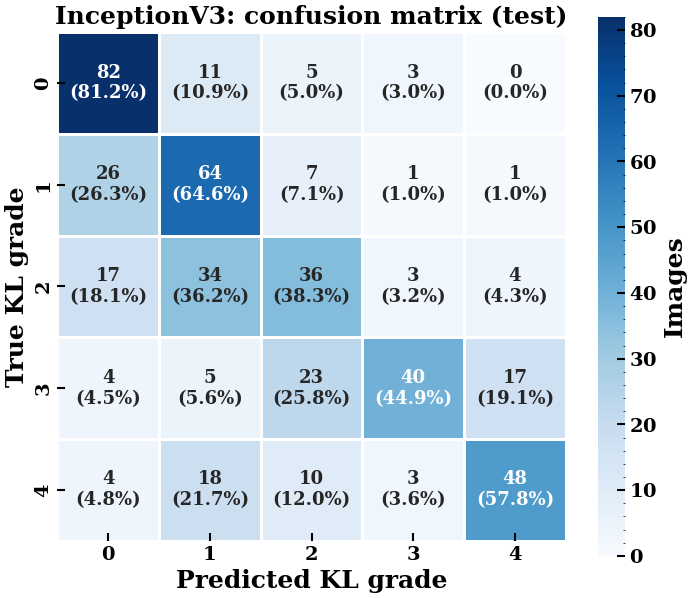

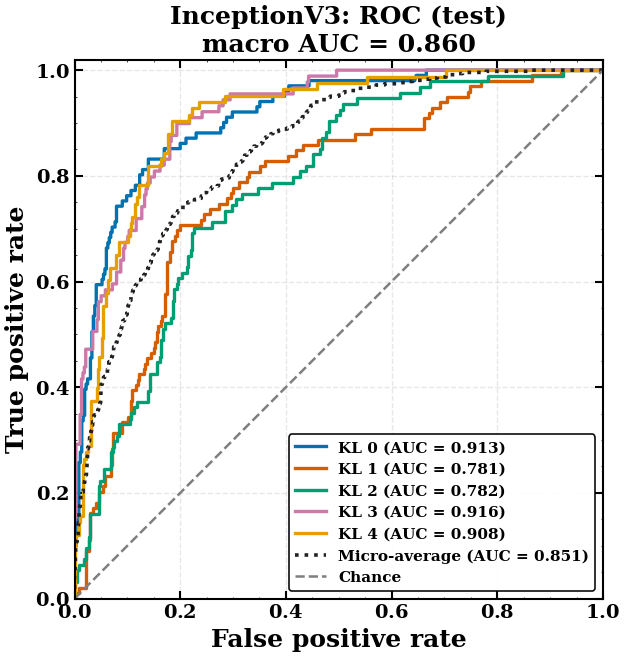


InceptionV3: test results (best epoch 63 of 73, early-stopped)
Test accuracy          : 0.5794   (test loss 1.0695)
Precision  weighted    : 0.6012   macro: 0.6063
Recall     weighted    : 0.5794   macro: 0.5738
F1 score   weighted    : 0.5743   macro: 0.5739
ROC AUC    macro       : 0.8601   micro: 0.8508
Val accuracy (best ep.): 0.6332   best val loss: 0.9625
Training time          : 17.0 min  (epoch 1 28 s, median epoch 13.8 s, time to best 14.7 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.6165    0.8119    0.7009       101
           1     0.4848    0.6465    0.5541        99
           2     0.4444    0.3830    0.4114        94
           3     0.8000    0.4494    0.5755        89
           4     0.6857    0.5783    0.6275        83

    accuracy                         0.5794       466
   macro avg     0.6063    0.5738    0.5739       466
weighted avg     0.6012    0.5794    0.5743       466



In [24]:
run_or_load("InceptionV3", run_keras_model);

### 5.12 InceptionResNetV2
299×299 · 1536-d features · tf preprocessing ([-1, 1])

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
InceptionResNetV2: input 299x299, 1536-d features -> Dense(5); params total 54,344,421, trainable 7,685
Epoch 1/300
51/51 - 39s - 760ms/step - accuracy: 0.2131 - loss: 1.6779 - val_accuracy: 0.2402 - val_loss: 1.5826
Epoch 2/300
51/51 - 14s - 274ms/step - accuracy: 0.2621 - loss: 1.5928 - val_accuracy: 0.3319 - val_loss: 1.5197
Epoch 3/300
51/51 - 18s - 346ms/step - accuracy: 0.2856 - loss: 1.5541 - val_accuracy: 0.3668 - val_loss: 1.4823
Epoch 4/300
51/51 - 14s - 279ms/step - accuracy: 0.3767 - loss: 1.4880 - val_accuracy: 0.3406 - val_loss: 1.4464
Epoch 5/300
51/51 - 14s - 274ms/step - accuracy: 0.3612 - loss: 1.4712 - val_accuracy: 0.3930 - val_loss: 1.4107
Epoch 6/300
51/51 - 17s - 342ms/step - accuracy: 0.3779 - loss: 1.4444 - val_accuracy: 0.4323 - val_loss: 1.3772
Epoch 7/300
51/51 - 14s - 275ms/step - accuracy: 0.4312 - loss: 1.4115 - val_accuracy: 0.4847 

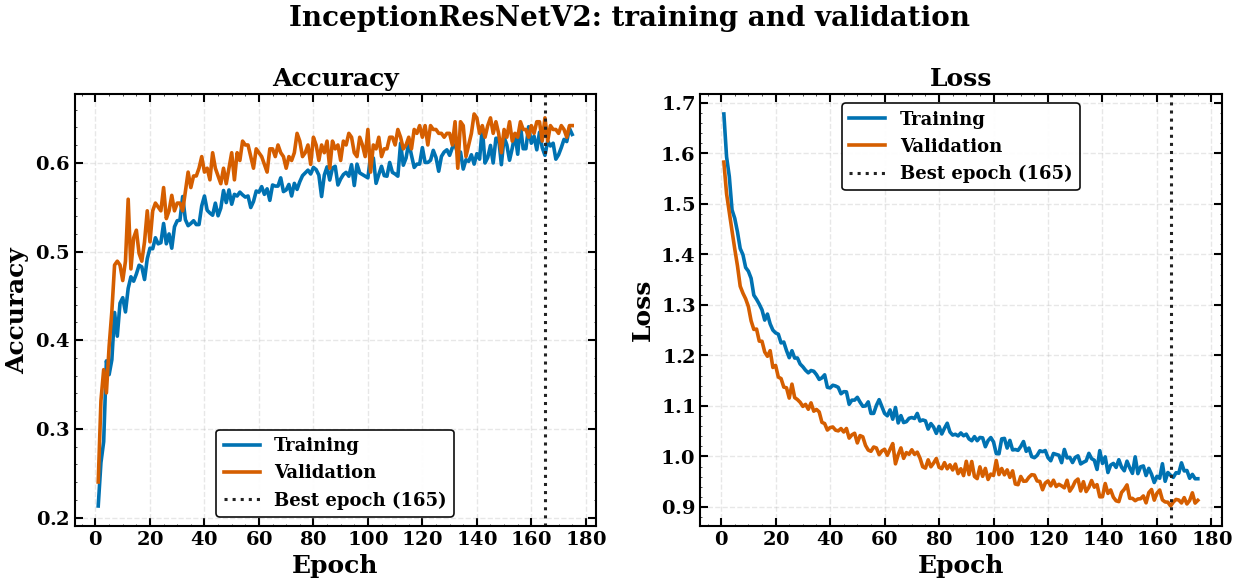

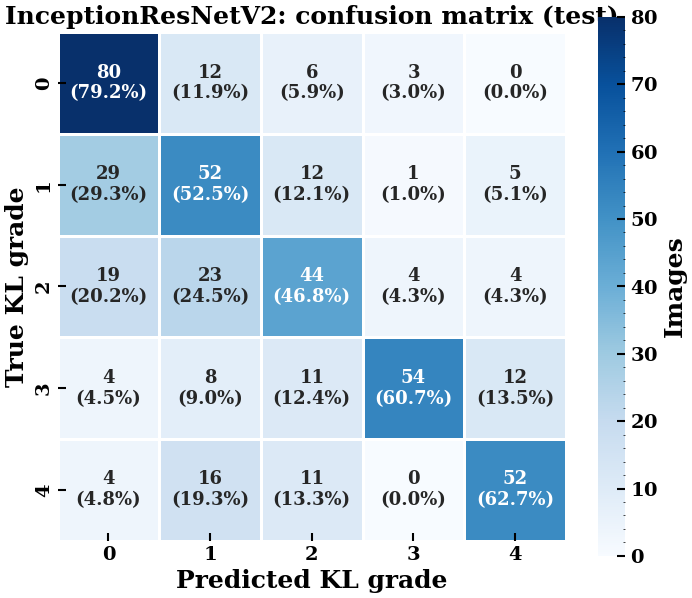

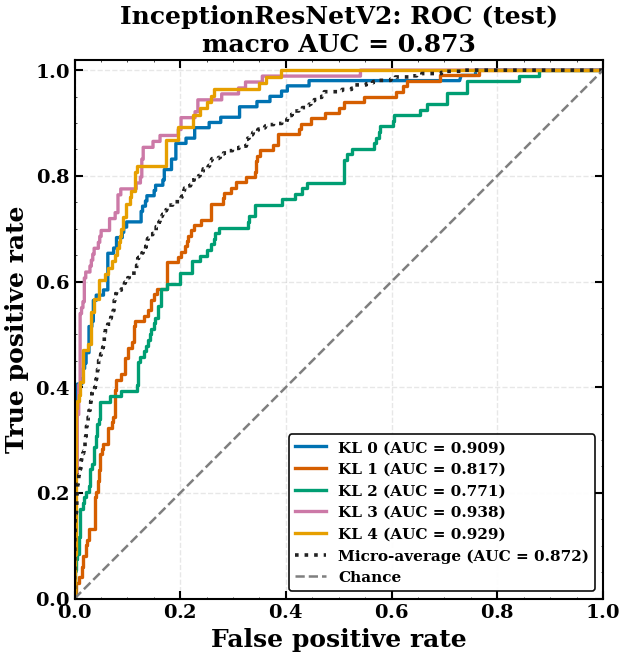


InceptionResNetV2: test results (best epoch 165 of 175, early-stopped)
Test accuracy          : 0.6052   (test loss 0.9957)
Precision  weighted    : 0.6259   macro: 0.6328
Recall     weighted    : 0.6052   macro: 0.6037
F1 score   weighted    : 0.6066   macro: 0.6093
ROC AUC    macro       : 0.8728   micro: 0.8720
Val accuracy (best ep.): 0.6507   best val loss: 0.9020
Training time          : 41.8 min  (epoch 1 36 s, median epoch 14.1 s, time to best 39.3 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5882    0.7921    0.6751       101
           1     0.4685    0.5253    0.4952        99
           2     0.5238    0.4681    0.4944        94
           3     0.8710    0.6067    0.7152        89
           4     0.7123    0.6265    0.6667        83

    accuracy                         0.6052       466
   macro avg     0.6328    0.6037    0.6093       466
weighted avg     0.6259    0.6052    0.6066       466



In [25]:
run_or_load("InceptionResNetV2", run_keras_model);

### 5.13 MobileNetV2
224×224 · 1280-d features · baseline (not a teacher candidate)

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
MobileNetV2: input 224x224, 1280-d features -> Dense(5); params total 2,264,389, trainable 6,405
Epoch 1/300


2026-09-15 23:23:03.919467: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:23:04.067538: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:23:04.219151: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:23:04.365082: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:23:04.508122: E external/local_xla/xla/stream_

51/51 - 30s - 589ms/step - accuracy: 0.2045 - loss: 1.9901 - val_accuracy: 0.2620 - val_loss: 1.7282
Epoch 2/300
51/51 - 13s - 260ms/step - accuracy: 0.2472 - loss: 1.7269 - val_accuracy: 0.2969 - val_loss: 1.6368
Epoch 3/300
51/51 - 10s - 189ms/step - accuracy: 0.2751 - loss: 1.6134 - val_accuracy: 0.3406 - val_loss: 1.5552
Epoch 4/300
51/51 - 10s - 192ms/step - accuracy: 0.3302 - loss: 1.5352 - val_accuracy: 0.3450 - val_loss: 1.4822
Epoch 5/300
51/51 - 13s - 246ms/step - accuracy: 0.3643 - loss: 1.4837 - val_accuracy: 0.3712 - val_loss: 1.4515
Epoch 6/300
51/51 - 10s - 196ms/step - accuracy: 0.3996 - loss: 1.4217 - val_accuracy: 0.4192 - val_loss: 1.3856
Epoch 7/300
51/51 - 10s - 192ms/step - accuracy: 0.4102 - loss: 1.3729 - val_accuracy: 0.4017 - val_loss: 1.3690
Epoch 8/300
51/51 - 12s - 242ms/step - accuracy: 0.4213 - loss: 1.3503 - val_accuracy: 0.4454 - val_loss: 1.3517
Epoch 9/300
51/51 - 10s - 195ms/step - accuracy: 0.4498 - loss: 1.3207 - val_accuracy: 0.4629 - val_loss: 1.

2026-09-15 23:38:16.955672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:38:17.105751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:38:17.247231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:38:17.395129: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 23:38:17.534852: E external/local_xla/xla/stream_

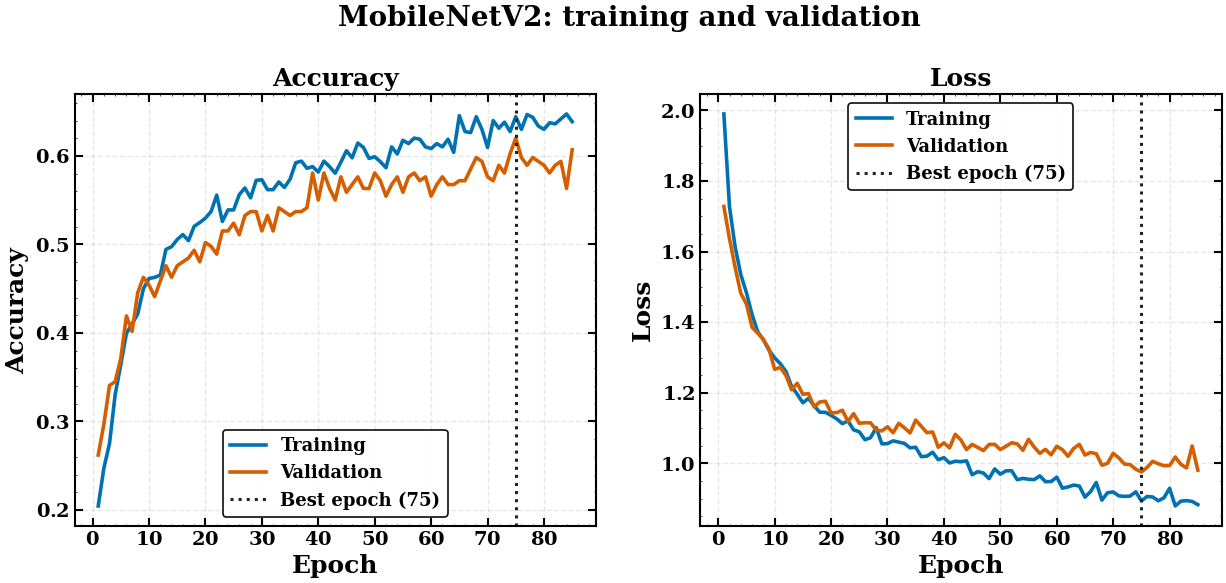

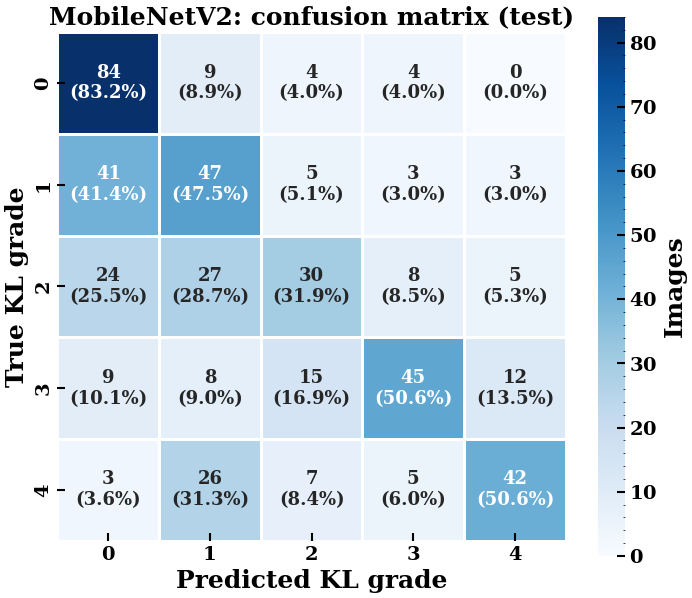

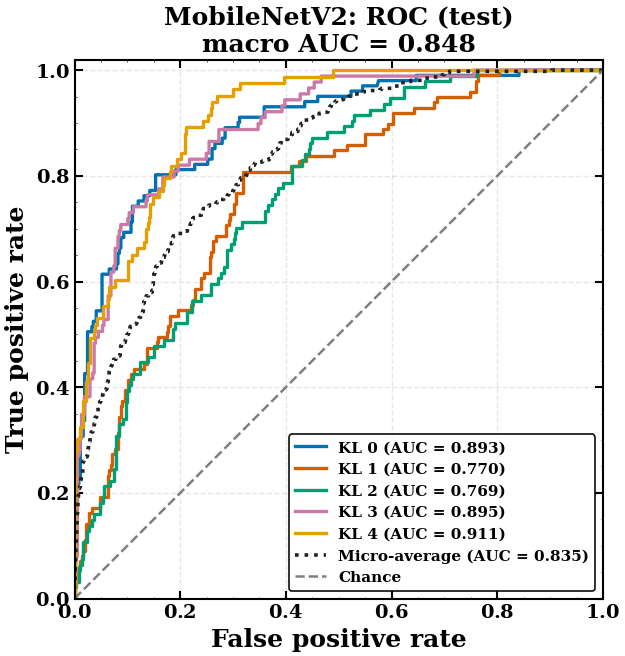


MobileNetV2: test results (best epoch 75 of 85, early-stopped)
Test accuracy          : 0.5322   (test loss 1.1202)
Precision  weighted    : 0.5505   macro: 0.5570
Recall     weighted    : 0.5322   macro: 0.5274
F1 score   weighted    : 0.5243   macro: 0.5254
ROC AUC    macro       : 0.8476   micro: 0.8354
Val accuracy (best ep.): 0.6201   best val loss: 0.9759
Training time          : 14.2 min  (epoch 1 30 s, median epoch 9.7 s, time to best 12.5 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5217    0.8317    0.6412       101
           1     0.4017    0.4747    0.4352        99
           2     0.4918    0.3191    0.3871        94
           3     0.6923    0.5056    0.5844        89
           4     0.6774    0.5060    0.5793        83

    accuracy                         0.5322       466
   macro avg     0.5570    0.5274    0.5254       466
weighted avg     0.5505    0.5322    0.5243       466



In [26]:
run_or_load("MobileNetV2", run_keras_model);

## 6. PyTorch / timm Models (Twins, PVTv2)
### 6.0 Setup
Twins and PVTv2 are not available in Keras, so they use timm (PyTorch). To keep the setup identical, they read their batches from **the same Keras generators**, with the same BPHE, resize, augmentation and batch size. They follow the same recipe:
- frozen ImageNet backbone in inference mode, with timm's own pooling (token average for Twins, spatial average for PVTv2) → a new `Linear(512, 5)` head;
- softmax cross-entropy, Adam with learning rate 1e-4 (`eps=1e-7` as in Keras), batch 32, at most 100 epochs;
- early stopping with Keras's exact rule (`val_loss`, patience 10, restore best).

Normalisation: timm's ImageNet mean/std, applied through `densenet.preprocess_input` (`/255`, then mean/std), which gives identical values.

In [27]:
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
TIMM_PRE = densenet.preprocess_input
TIMM_MODELS = {
    "Twins-SVT-S": dict(timm_name="twins_svt_small.in1k", size=224, family="Transformer"),
    "PVTv2-B2": dict(timm_name="pvt_v2_b2.in1k", size=224, family="Transformer"),
}
assert list(TIMM_MODELS) == TIMM_ORDER

# The Keras 'torch' preprocessing must equal (BPHE / 255 - mean) / std
_x = (np.random.RandomState(0).rand(64, 64, 3) * 255).astype(np.float32)
_expected = (bphe_uint8(_x.copy()) / 255.0 - np.array(IMAGENET_MEAN)) / np.array(IMAGENET_STD)
assert np.allclose(make_bphe(TIMM_PRE)(_x.copy()), _expected, atol=1e-5)


class KerasLikeEarlyStopping:
    """Same rule as keras.callbacks.EarlyStopping(monitor, patience, min_delta=0, restore_best_weights=True)."""

    def __init__(self, patience):
        self.patience, self.wait = patience, 0
        self.best, self.best_epoch, self.best_state, self.stopped_epoch = np.inf, 0, None, 0

    def step(self, epoch, value, module):
        """Call once per epoch (0-based). Returns True when training should stop."""
        if self.best_state is None:
            self.best_state = {k: v.detach().clone() for k, v in module.state_dict().items()}
        self.wait += 1
        if value < self.best:
            self.best, self.best_epoch, self.wait = value, epoch, 0
            self.best_state = {k: v.detach().clone() for k, v in module.state_dict().items()}
            return False
        if self.wait >= self.patience and epoch > 0:
            self.stopped_epoch = epoch
            return True
        return False


def build_timm_model(name):
    spec = TIMM_MODELS[name]
    model = timm.create_model(spec["timm_name"], pretrained=True, num_classes=NUM_CLASSES)
    data_cfg = timm.data.resolve_model_data_config(model)
    assert np.allclose(data_cfg["mean"], IMAGENET_MEAN) and np.allclose(data_cfg["std"], IMAGENET_STD)
    assert data_cfg["input_size"][-1] == spec["size"]

    model.requires_grad_(False)                  # freeze the backbone
    head = model.get_classifier()
    head.requires_grad_(True)                    # train only the new Linear head
    nn.init.xavier_uniform_(head.weight)         # same initialisation as a Keras Dense layer (glorot_uniform)
    nn.init.zeros_(head.bias)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    assert n_trainable == model.num_features * NUM_CLASSES + NUM_CLASSES, n_trainable
    return model.to(DEVICE).eval(), head


def iter_torch_batches(gen):
    """Yield (NCHW float tensor, int label tensor) batches from a Keras DirectoryIterator."""
    for i in range(len(gen)):
        x, y = gen[i]
        yield (torch.from_numpy(np.ascontiguousarray(x.transpose(0, 3, 1, 2))).float().to(DEVICE),
               torch.from_numpy(y.argmax(axis=1)).long().to(DEVICE))


def train_timm_one_epoch(model, gen, optimizer, loss_fn):
    model.eval()                                 # frozen layers stay in inference mode, as in Keras
    total_loss, correct, seen = 0.0, 0, 0
    for xb, yb in iter_torch_batches(gen):
        logits = model(xb)
        loss = loss_fn(logits, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        seen += yb.size(0)
    gen.on_epoch_end()                           # reshuffle for the next epoch, as Keras does
    return total_loss / seen, correct / seen


@torch.no_grad()
def predict_timm(model, gen, loss_fn):
    model.eval()
    probs, labels, total_loss, seen = [], [], 0.0, 0
    for xb, yb in iter_torch_batches(gen):
        logits = model(xb)
        total_loss += loss_fn(logits, yb).item() * yb.size(0)
        seen += yb.size(0)
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        labels.append(yb.cpu().numpy())
    return np.concatenate(probs), np.concatenate(labels), total_loss / seen


def _backbone_checksum(model, head):
    head_ids = {id(p) for p in head.parameters()}
    return float(sum(p.detach().double().sum().item() for p in model.parameters() if id(p) not in head_ids))


def run_timm_model(name):
    spec = TIMM_MODELS[name]
    out = OUT_DIR / name
    out.mkdir(parents=True, exist_ok=True)
    keras.utils.set_random_seed(CFG["SEED"])
    torch.manual_seed(CFG["SEED"])

    preprocess = make_bphe(TIMM_PRE)
    train_gen, val_gen, test_gen = make_generators(spec["size"], preprocess, seed=CFG["SEED"])
    model, head = build_timm_model(name)
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = model.num_features * NUM_CLASSES + NUM_CLASSES
    print(f"{name} ({spec['timm_name']}): input {spec['size']}x{spec['size']}, {model.num_features}-d features -> "
          f"Linear({NUM_CLASSES}); params total {n_params:,}, trainable {n_trainable:,}; device {DEVICE}")
    checksum_before = _backbone_checksum(model, head)

    optimizer = torch.optim.Adam(head.parameters(), lr=CFG["LR"], eps=1e-7)
    loss_fn = nn.CrossEntropyLoss()
    early_stop = KerasLikeEarlyStopping(CFG["PATIENCE"])
    rows, start = [], time.perf_counter()
    for epoch in range(CFG["MAX_EPOCHS"]):
        t0 = time.perf_counter()
        train_loss, train_acc = train_timm_one_epoch(model, train_gen, optimizer, loss_fn)
        val_prob, val_y, val_loss = predict_timm(model, val_gen, loss_fn)
        val_gen.on_epoch_end()
        val_acc = float((val_prob.argmax(axis=1) == val_y).mean())
        dt = time.perf_counter() - t0
        rows.append(dict(epoch=epoch + 1, accuracy=train_acc, loss=train_loss, val_accuracy=val_acc,
                         val_loss=val_loss, epoch_time_s=dt))
        print(f"Epoch {epoch + 1}/{CFG['MAX_EPOCHS']} - {dt:.0f}s - accuracy: {train_acc:.4f} - loss: {train_loss:.4f}"
              f" - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}")
        if early_stop.step(epoch, val_loss, head):
            print(f"Epoch {epoch + 1}: early stopping")
            break
    fit_time = time.perf_counter() - start
    hist = pd.DataFrame(rows)

    # Restore the best-epoch head and check it on the validation set
    head.load_state_dict(early_stop.best_state)
    print(f"Restoring model weights from the end of the best epoch: {early_stop.best_epoch + 1}.")
    _, _, val_loss_check = predict_timm(model, make_eval_generator(VAL_DIR, spec["size"], preprocess), loss_fn)
    restore_ok = bool(np.isclose(val_loss_check, hist["val_loss"].iloc[early_stop.best_epoch], rtol=1e-3, atol=1e-4))
    if not restore_ok:
        print(f"WARNING: restored val_loss {val_loss_check:.5f} != best-epoch val_loss "
              f"{hist['val_loss'].iloc[early_stop.best_epoch]:.5f}")
    backbone_unchanged = bool(np.isclose(_backbone_checksum(model, head), checksum_before, rtol=0, atol=1e-6))
    if not backbone_unchanged:
        print("WARNING: frozen backbone weights changed during training")

    prob, y_true, test_loss = predict_timm(model, test_gen, loss_fn)
    assert np.array_equal(y_true, test_gen.classes), "Test label order mismatch"

    if CFG["SAVE_WEIGHTS"]:
        torch.save({"timm_name": spec["timm_name"], "num_classes": NUM_CLASSES,
                    "head_state_dict": head.state_dict()}, out / "head_best.pt")

    info = common_info(name, "PyTorch (timm)", spec["family"], spec["size"], f"{TIMM_PRE.__module__} (ImageNet mean/std)",
                       "average pooling -> Linear(5)", n_params, n_trainable,
                       train_gen.samples, val_gen.samples, test_gen.samples)
    info.update(timm_name=spec["timm_name"])
    info.update(history_info(hist, early_stop.best_epoch, fit_time, early_stop.stopped_epoch > 0))
    info.update(test_loss=float(test_loss), restore_check_val_loss=float(val_loss_check),
                restore_check_ok=restore_ok, backbone_unchanged=backbone_unchanged)

    res = finalize_run(name, info, hist, y_true, prob, test_gen.filenames)
    del model, head, optimizer
    cleanup_backend()
    return res

### 6.1 Twins-SVT-S
`twins_svt_small.in1k` · 224×224 · 512-d features

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
Twins-SVT-S (twins_svt_small.in1k): input 224x224, 512-d features -> Linear(5); params total 23,550,341, trainable 2,565; device cuda
Epoch 1/300 - 15s - accuracy: 0.2138 - loss: 1.7895 - val_accuracy: 0.2358 - val_loss: 1.7331
Epoch 2/300 - 14s - accuracy: 0.2206 - loss: 1.6809 - val_accuracy: 0.2620 - val_loss: 1.6654
Epoch 3/300 - 14s - accuracy: 0.2454 - loss: 1.6286 - val_accuracy: 0.2664 - val_loss: 1.6135
Epoch 4/300 - 13s - accuracy: 0.2794 - loss: 1.5773 - val_accuracy: 0.3057 - val_loss: 1.5689
Epoch 5/300 - 13s - accuracy: 0.3240 - loss: 1.5298 - val_accuracy: 0.3231 - val_loss: 1.5348
Epoch 6/300 - 14s - accuracy: 0.3377 - loss: 1.5084 - val_accuracy: 0.3362 - val_loss: 1.5050
Epoch 7/300 - 13s - accuracy: 0.3333 - loss: 1.4915 - val_accuracy: 0.3581 - val_loss: 1.4790
Epoch 8/300 - 13s - accuracy: 0.3798 - loss: 1.4523 - val_accuracy: 0.3843 - val_los

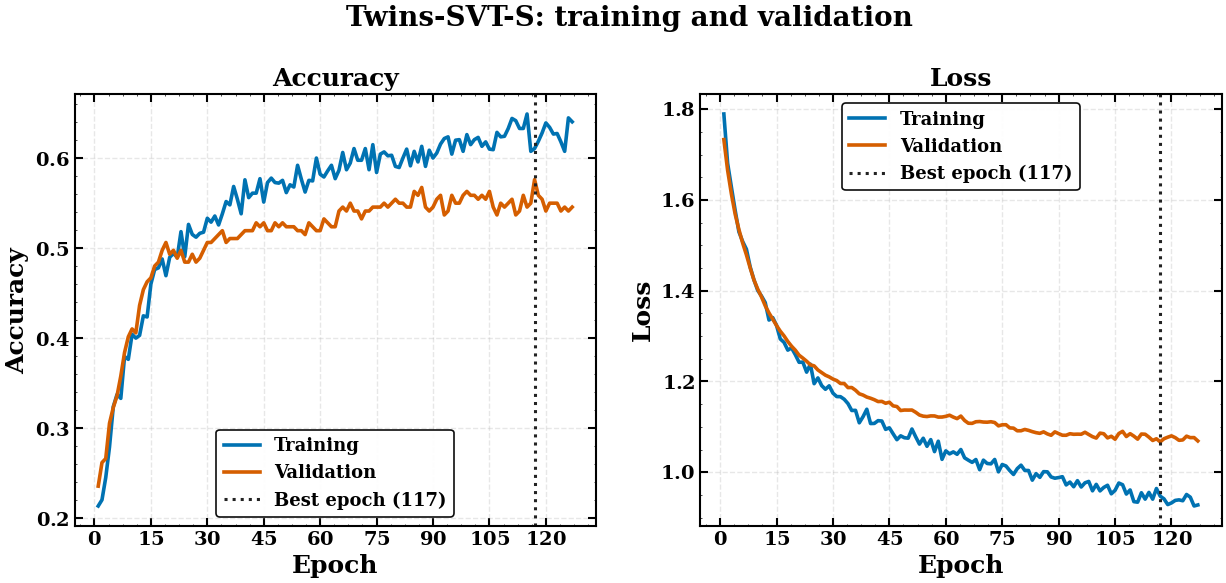

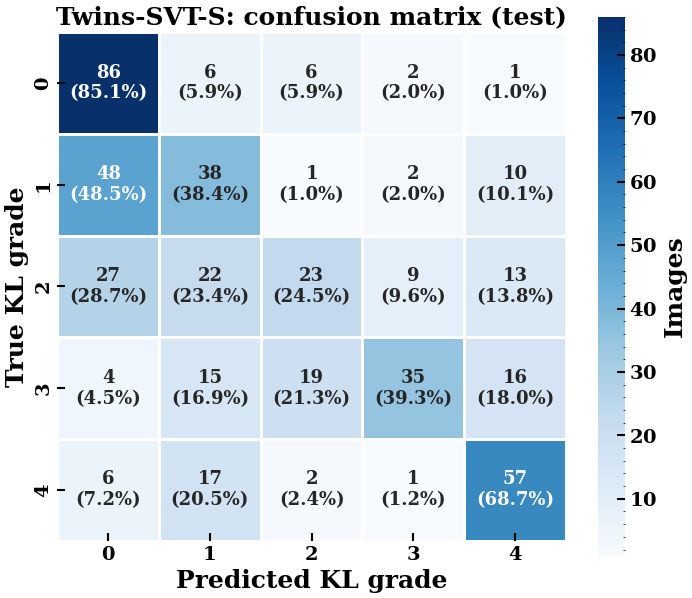

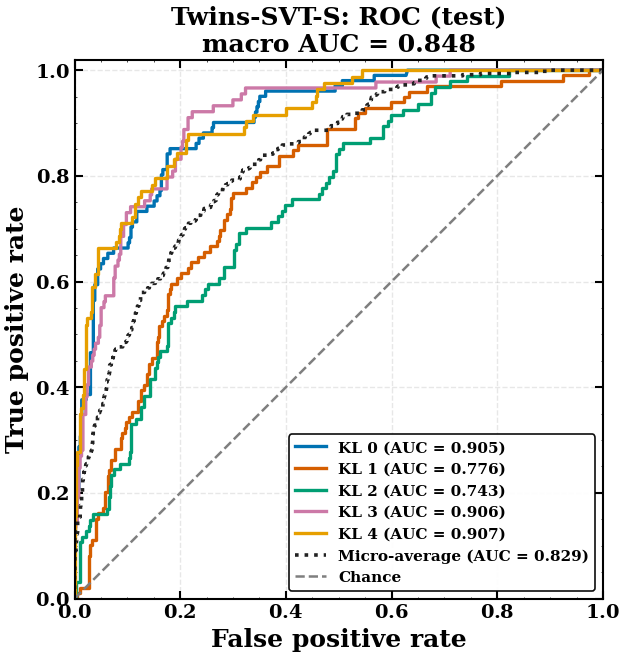


Twins-SVT-S: test results (best epoch 117 of 127, early-stopped)
Test accuracy          : 0.5129   (test loss 1.1427)
Precision  weighted    : 0.5234   macro: 0.5287
Recall     weighted    : 0.5129   macro: 0.5120
F1 score   weighted    : 0.4927   macro: 0.4952
ROC AUC    macro       : 0.8476   micro: 0.8287
Val accuracy (best ep.): 0.5764   best val loss: 1.0669
Training time          : 27.8 min  (epoch 1 15 s, median epoch 13.1 s, time to best 25.6 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5029    0.8515    0.6324       101
           1     0.3878    0.3838    0.3858        99
           2     0.4510    0.2447    0.3172        94
           3     0.7143    0.3933    0.5072        89
           4     0.5876    0.6867    0.6333        83

    accuracy                         0.5129       466
   macro avg     0.5287    0.5120    0.4952       466
weighted avg     0.5234    0.5129    0.4927       466



In [28]:
run_or_load("Twins-SVT-S", run_timm_model);

### 6.2 PVTv2-B2
`pvt_v2_b2.in1k` · 224×224 · 512-d features

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.
PVTv2-B2 (pvt_v2_b2.in1k): input 224x224, 512-d features -> Linear(5); params total 24,852,421, trainable 2,565; device cuda
Epoch 1/300 - 14s - accuracy: 0.2119 - loss: 1.9897 - val_accuracy: 0.2402 - val_loss: 1.8330
Epoch 2/300 - 13s - accuracy: 0.2323 - loss: 1.7873 - val_accuracy: 0.2707 - val_loss: 1.6772
Epoch 3/300 - 13s - accuracy: 0.2590 - loss: 1.6884 - val_accuracy: 0.3013 - val_loss: 1.5884
Epoch 4/300 - 13s - accuracy: 0.2968 - loss: 1.6394 - val_accuracy: 0.3581 - val_loss: 1.5266
Epoch 5/300 - 13s - accuracy: 0.3154 - loss: 1.5783 - val_accuracy: 0.3843 - val_loss: 1.4771
Epoch 6/300 - 13s - accuracy: 0.3470 - loss: 1.5193 - val_accuracy: 0.4061 - val_loss: 1.4366
Epoch 7/300 - 13s - accuracy: 0.3625 - loss: 1.4885 - val_accuracy: 0.4192 - val_loss: 1.4056
Epoch 8/300 - 13s - accuracy: 0.3835 - loss: 1.4461 - val_accuracy: 0.4410 - val_loss: 1.3750

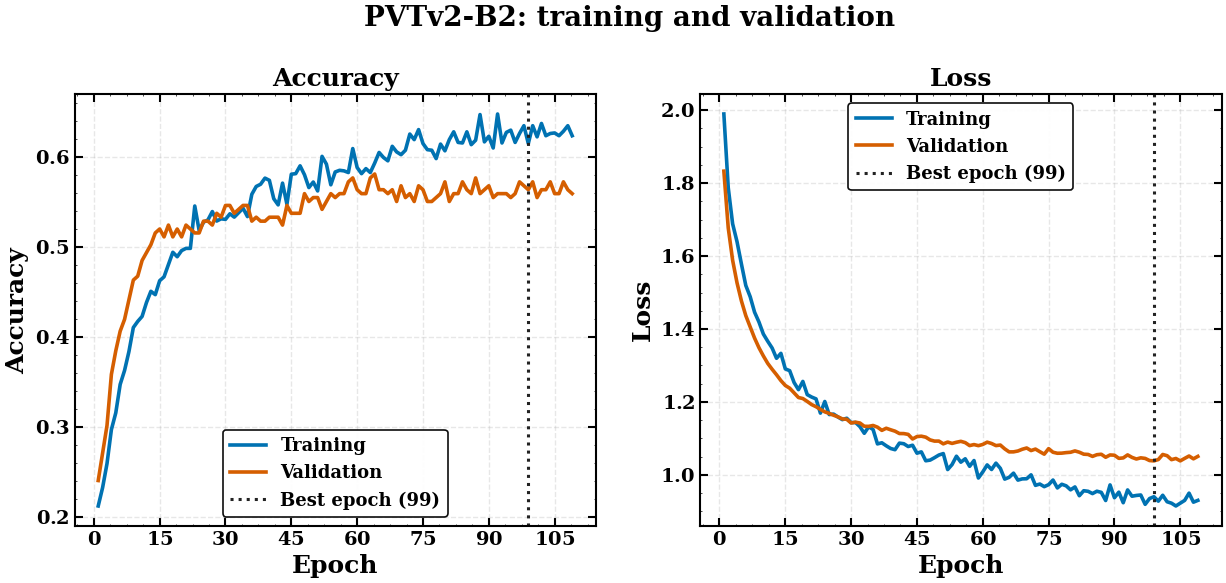

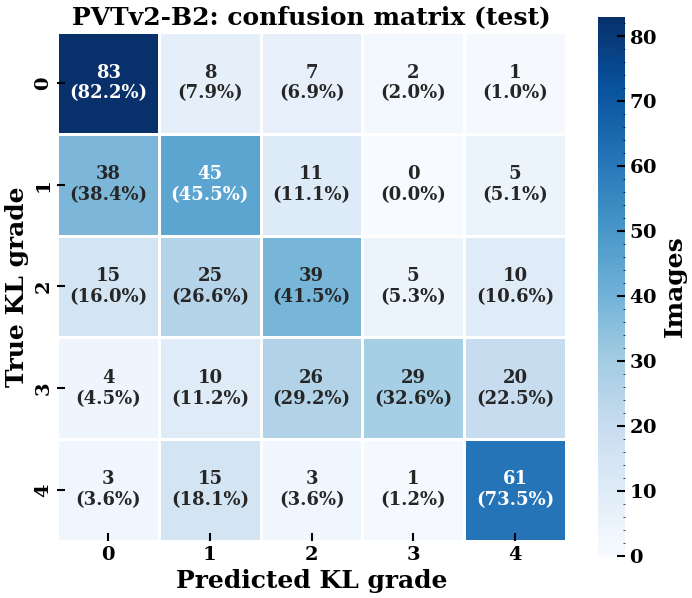

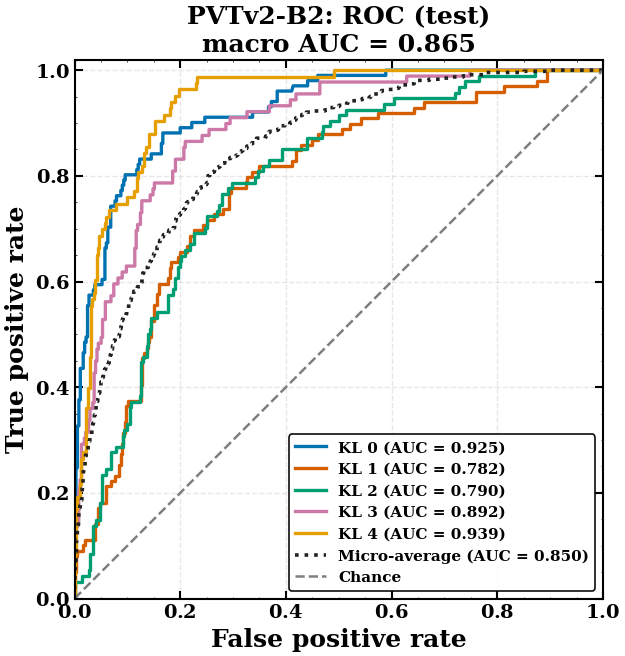


PVTv2-B2: test results (best epoch 99 of 109, early-stopped)
Test accuracy          : 0.5515   (test loss 1.0753)
Precision  weighted    : 0.5718   macro: 0.5767
Recall     weighted    : 0.5515   macro: 0.5504
F1 score   weighted    : 0.5382   macro: 0.5395
ROC AUC    macro       : 0.8654   micro: 0.8505
Val accuracy (best ep.): 0.5633   best val loss: 1.0382
Training time          : 22.9 min  (epoch 1 14 s, median epoch 12.5 s, time to best 20.8 min)

Classification report (test):
              precision    recall  f1-score   support

           0     0.5804    0.8218    0.6803       101
           1     0.4369    0.4545    0.4455        99
           2     0.4535    0.4149    0.4333        94
           3     0.7838    0.3258    0.4603        89
           4     0.6289    0.7349    0.6778        83

    accuracy                         0.5515       466
   macro avg     0.5767    0.5504    0.5395       466
weighted avg     0.5718    0.5515    0.5382       466



In [29]:
run_or_load("PVTv2-B2", run_timm_model);

## 7. Summary & Comparison
### 7.1 Results table
One row per finished model, read from `results/<ModelName>/metrics.json`, plus:
- **Custom-ENB5 (reference)**: notebook 3's printed results. It was trained with a different recipe (fine-tuned EfficientNetB5 with a 4-layer head, RMSprop 1e-4, 224 px, no BPHE, no early stopping, last-epoch weights), so compare it on test metrics only.
- `test_accuracy_6.1_run`: the test accuracy of the earlier 6.1 run of the same model (100 epochs, last-epoch weights), for reference. The 6.1 EfficientNetB0 and B5 runs read `/mnt/d/FA019/SplitDataset` rather than `new/SplittedDataset`, and the 6.1 runs saw 229–230 validation images.

In [15]:
REFERENCE = dict(
    model="Custom-ENB5 (reference)", framework="Keras", family="EfficientNet", input_size=224,
    recipe="notebook 3: fine-tuned EfficientNetB5 + 4-layer head, RMSprop 1e-4, no early stopping",
    params_total=32_189_180, epochs_run=100, best_epoch=100, stopped_early=False,
    final_val_accuracy=0.8952, max_val_accuracy=0.9214, val_accuracy_at_best=0.8952,
    test_accuracy=0.8948, test_precision_weighted=0.8945, test_recall_weighted=0.8948, test_f1_weighted=0.8942,
    test_precision_macro=0.90, test_recall_macro=0.90, test_f1_macro=0.90, fit_time_min=96.2,
)
PREVIOUS_61_TEST_ACC = {"EfficientNetB0": 0.5987, "EfficientNetB4": 0.6459, "EfficientNetB5": 0.6223,
                        "ResNet50": 0.6009, "ResNet101": 0.6009, "DenseNet121": 0.5622, "DenseNet201": 0.6094,
                        "InceptionV3": 0.5687, "InceptionResNetV2": 0.6094}

finished = [m for m in ALL_MODELS if (OUT_DIR / m / "metrics.json").exists()]
missing = [m for m in ALL_MODELS if m not in finished]
print(f"Finished: {len(finished)}/{len(ALL_MODELS)}" + (f"  (missing: {', '.join(missing)})" if missing else ""))

records = [load_result(m, show=False) for m in finished]
COLUMNS = ["model", "framework", "family", "input_size", "params_total", "epochs_run", "best_epoch", "stopped_early",
           "best_val_loss", "val_accuracy_at_best", "max_val_accuracy", "test_accuracy", "test_precision_weighted",
           "test_recall_weighted", "test_f1_weighted", "test_precision_macro", "test_recall_macro", "test_f1_macro",
           "test_auc_macro", "test_auc_micro", "fit_time_min", "time_to_best_s", "epoch1_s", "median_epoch_s"]
summary = pd.DataFrame(records).reindex(columns=COLUMNS)
summary["time_to_best_min"] = summary.pop("time_to_best_s") / 60
summary["test_accuracy_6.1_run"] = summary["model"].map(PREVIOUS_61_TEST_ACC)
summary_all = pd.concat([summary, pd.DataFrame([REFERENCE]).reindex(columns=summary.columns)], ignore_index=True)
summary_all.to_csv(SUMMARY_DIR / "summary.csv", index=False)

advisor = summary_all[["model", "val_accuracy_at_best", "test_accuracy", "test_f1_macro", "fit_time_min"]].rename(
    columns={"model": "Model Name", "val_accuracy_at_best": "Validation Accuracy", "test_accuracy": "Test Accuracy",
             "test_f1_macro": "Test Macro F1", "fit_time_min": "Training Time (min)"})
advisor.to_csv(SUMMARY_DIR / "advisor_table.csv", index=False)

shown = summary_all.sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
metric_cols = ["val_accuracy_at_best", "test_accuracy", "test_f1_weighted", "test_f1_macro", "test_auc_macro"]
try:
    display(shown.style.format(precision=4, na_rep="-").highlight_max(subset=metric_cols, color="#cfe8ff"))
except Exception:  # jinja2 not installed
    display(shown.round(4))
print("Saved:", SUMMARY_DIR / "summary.csv", "and", SUMMARY_DIR / "advisor_table.csv")

Finished: 17/17


,model,framework,family,input_size,params_total,epochs_run,best_epoch,stopped_early,best_val_loss,val_accuracy_at_best,max_val_accuracy,test_accuracy,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_precision_macro,test_recall_macro,test_f1_macro,test_auc_macro,test_auc_micro,fit_time_min,epoch1_s,median_epoch_s,time_to_best_min,test_accuracy_6.1_run
0,Custom-ENB5 (reference),Keras,EfficientNet,224,32189180,100,100,False,-,0.8952,0.9214,0.8948,0.8945,0.8948,0.8942,0.9000,0.9000,0.9000,-,-,96.2000,-,-,-,-
1,InceptionResNetV2,Keras,Inception,299,54344421,175,165,True,0.9020,0.6507,0.6550,0.6052,0.6259,0.6052,0.6066,0.6328,0.6037,0.6093,0.8728,0.8720,41.7635,35.9067,14.1199,39.3045,0.6094
2,ResNet50,Keras,ResNet,224,23597957,67,57,True,0.8534,0.6376,0.6856,0.6052,0.6297,0.6052,0.6006,0.6366,0.6064,0.6046,0.8781,0.8766,11.1246,19.0224,9.7959,9.4710,0.6009
3,EfficientNetB7,Keras,EfficientNet,600,64110492,120,110,True,1.0011,0.6376,0.6507,0.5901,0.6303,0.5901,0.5923,0.6304,0.5898,0.5931,0.8652,0.8619,96.4226,140.0119,45.0315,87.4287,-
4,DenseNet201,Keras,DenseNet,224,18331589,100,90,True,0.9417,0.6114,0.6245,0.5944,0.6090,0.5944,0.5873,0.6140,0.5945,0.5896,0.8844,0.8839,17.5105,50.4383,10.0734,15.8386,0.6094
5,EfficientNetB4,Keras,EfficientNet,380,17682788,131,121,True,0.9146,0.6288,0.6332,0.5944,0.5888,0.5944,0.5829,0.5906,0.5893,0.5815,0.8799,0.8743,45.1892,80.1705,20.1663,41.7886,0.6459
6,EfficientNetB2,Keras,EfficientNet,260,7775614,116,106,True,0.9124,0.6157,0.6419,0.5837,0.5991,0.5837,0.5731,0.6041,0.5828,0.5750,0.8750,0.8671,22.9967,55.4590,11.4138,21.0737,-
7,InceptionV3,Keras,Inception,299,21813029,73,63,True,0.9625,0.6332,0.6419,0.5794,0.6012,0.5794,0.5743,0.6063,0.5738,0.5739,0.8601,0.8508,16.9870,28.4456,13.7511,14.6919,0.5687
8,EfficientNetB6,Keras,EfficientNet,528,40971668,190,180,True,0.9880,0.6638,0.6638,0.5751,0.5930,0.5751,0.5708,0.5958,0.5700,0.5698,0.8718,0.8662,113.9751,121.1152,35.3607,108.1348,-
9,EfficientNetB0,Keras,EfficientNet,224,4055976,129,119,True,0.9938,0.5939,0.6157,0.5708,0.5812,0.5708,0.5625,0.5895,0.5719,0.5677,0.8607,0.8584,21.3589,42.2928,9.6819,19.7582,0.5987


Saved: results/_summary/summary.csv and results/_summary/advisor_table.csv


### 7.2 Comparison figures
Figures are saved to `results/_summary/figures/`:
1. test metrics per model;
2. training time, split into the first epoch (which includes XLA compilation for Keras) and the remaining epochs;
3. macro F1 against training time;
4. validation loss of every model.

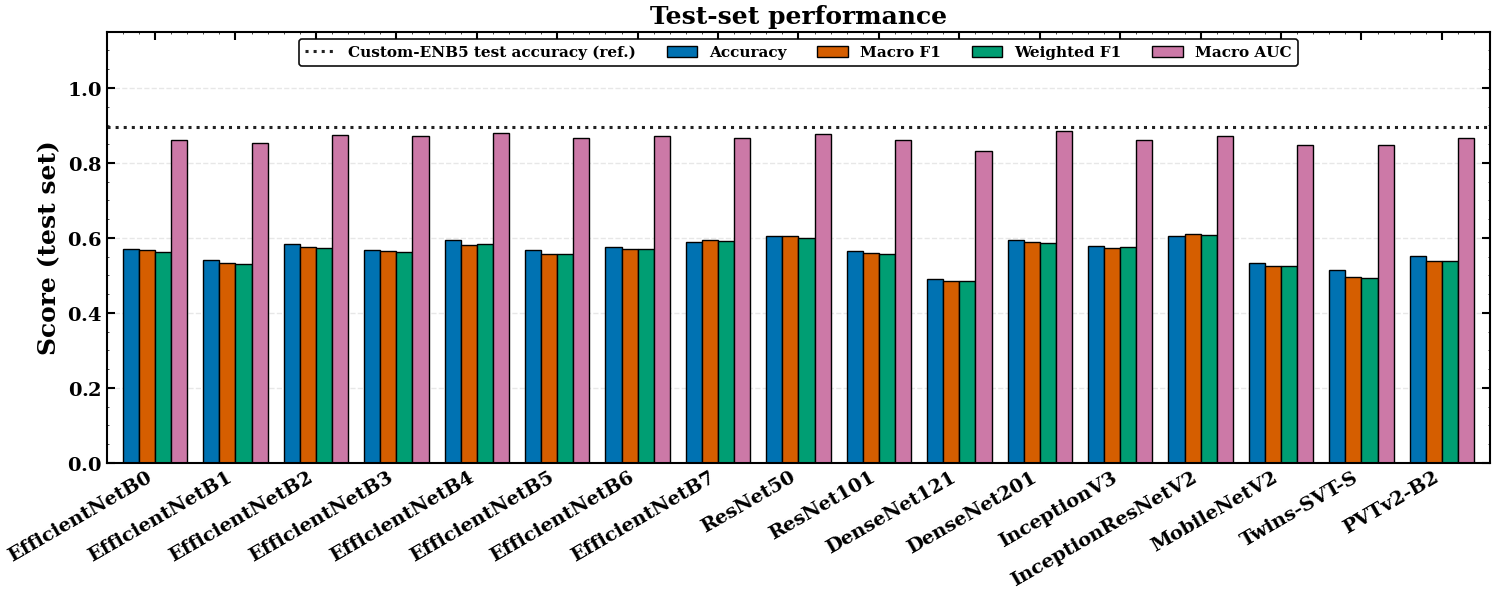

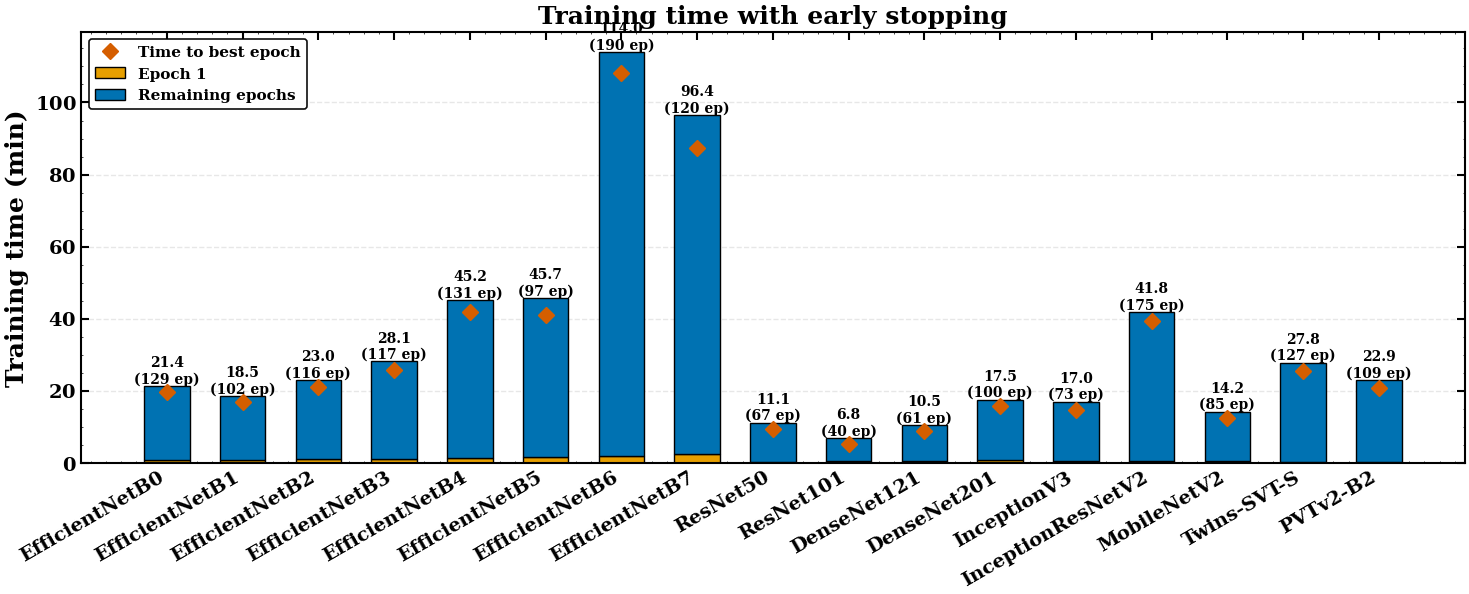

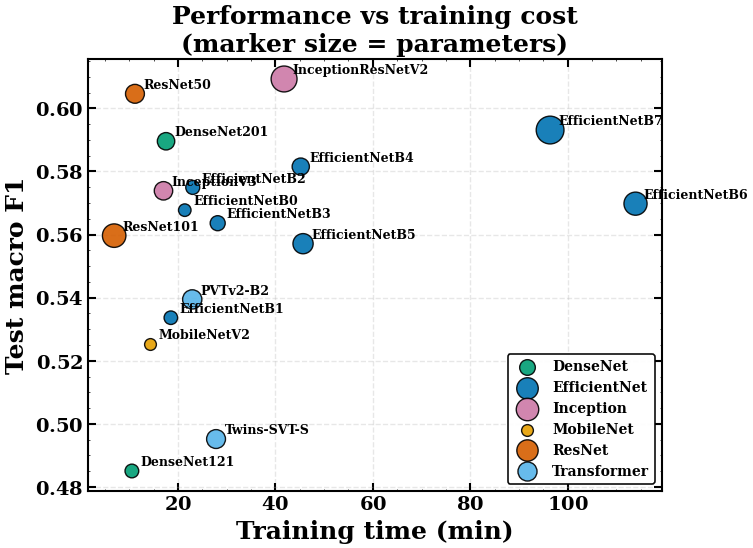

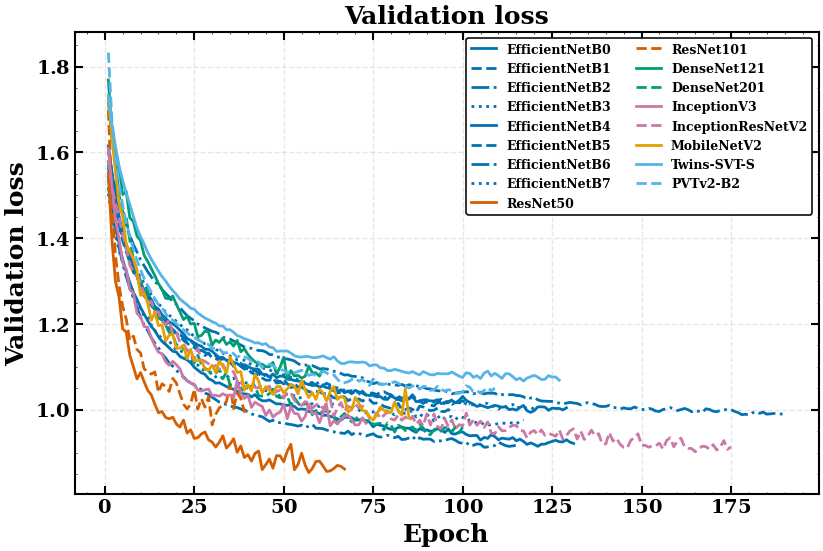

In [16]:
FIG_SUM = SUMMARY_DIR / "figures"
df = summary.copy()

if df.empty:
    print("No finished models yet.")
else:
    names, x = df["model"].tolist(), np.arange(len(df))

    # 1) Test metrics
    metrics = [("test_accuracy", "Accuracy"), ("test_f1_macro", "Macro F1"),
               ("test_f1_weighted", "Weighted F1"), ("test_auc_macro", "Macro AUC")]
    w = 0.8 / len(metrics)
    fig, ax = plt.subplots(figsize=(max(8.6, 1.05 * len(df)), 5.6))
    for i, (key, label) in enumerate(metrics):
        ax.bar(x + (i - (len(metrics) - 1) / 2) * w, df[key], w, label=label, color=OKABE_ITO[i],
               edgecolor="black", linewidth=1.0)
    ax.axhline(REFERENCE["test_accuracy"], color=C_REF, ls=":", lw=2.2, label="Custom-ENB5 test accuracy (ref.)")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_xlim(-0.6, len(df) - 0.4)
    ax.set_ylim(0, 1.15)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel("Score (test set)")
    ax.set_title("Test-set performance")
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(ncol=5, fontsize=11, loc="upper center")
    save_fig(fig, FIG_SUM / "test_metrics")

    # 2) Training time
    first = df["epoch1_s"] / 60
    rest = df["fit_time_min"] - first
    fig, ax = plt.subplots(figsize=(max(8.6, 1.05 * len(df)), 5.6))
    ax.bar(x, first, 0.6, color=OKABE_ITO[4], edgecolor="black", linewidth=1.0, label="Epoch 1")
    ax.bar(x, rest, 0.6, bottom=first, color=OKABE_ITO[0], edgecolor="black", linewidth=1.0, label="Remaining epochs")
    ax.plot(x, df["time_to_best_min"], ls="none", marker="D", ms=8, color=C_VAL, label="Time to best epoch")
    for xi, total, n_ep in zip(x, df["fit_time_min"], df["epochs_run"]):
        ax.text(xi, total, f"{total:.1f}\n({n_ep} ep)", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_ylabel("Training time (min)")
    ax.set_title("Training time with early stopping")
    ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(fontsize=11, loc="upper left")
    save_fig(fig, FIG_SUM / "training_time")

    # 3) Macro F1 vs training time
    fig, ax = plt.subplots(figsize=(7.4, 5.6))
    sizes = 60 + 340 * df["params_total"] / df["params_total"].max()
    for fam, grp in df.groupby("family"):
        ax.scatter(grp["fit_time_min"], grp["test_f1_macro"], s=sizes[grp.index], color=FAMILY_COLORS.get(fam, "#7F7F7F"),
                   edgecolor="black", linewidth=1.0, label=fam, alpha=0.9)
    for _, r in df.iterrows():
        ax.annotate(r["model"], (r["fit_time_min"], r["test_f1_macro"]), textcoords="offset points", xytext=(6, 4),
                    fontsize=9, fontweight="bold")
    ax.set_xlabel("Training time (min)")
    ax.set_ylabel("Test macro F1")
    ax.set_title("Performance vs training cost\n(marker size = parameters)")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(fontsize=10, loc="best")
    save_fig(fig, FIG_SUM / "f1_vs_time")

    # 4) Validation loss of every model
    fig, ax = plt.subplots(figsize=(9.6, 6.0))
    styles = ["-", "--", "-.", ":", (0, (5, 1)), (0, (3, 1, 1, 1)), (0, (1, 1)), (0, (5, 5))]
    fam_count = {}
    for _, r in df.iterrows():
        h = pd.read_csv(OUT_DIR / r["model"] / "history.csv")
        k = fam_count.get(r["family"], 0)
        fam_count[r["family"]] = k + 1
        ax.plot(h["epoch"], h["val_loss"], color=FAMILY_COLORS.get(r["family"], "#7F7F7F"), ls=styles[k % 4],
                lw=2.0, label=r["model"])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation loss")
    ax.set_title("Validation loss")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(ncol=2, fontsize=9, loc="upper right")
    save_fig(fig, FIG_SUM / "val_loss_all")

### 7.3 Reading the results
- **Choosing a teacher.** Rank models by test macro F1 and accuracy (7.1). Differences of about 3 accuracy points or less (roughly 14 of the 466 test images) are within run-to-run noise.
- **Validation accuracy** in the tables is the value at the best epoch, i.e. the weights that were restored and tested.
- **Training time** covers `fit` only. Epoch 1 includes XLA compilation for the Keras models. PyTorch and Keras times are not directly comparable, because data loading is shared and CPU-bound.
- **Custom-ENB5** uses a different, fine-tuned recipe. It shows what full fine-tuning reaches, not a like-for-like comparison.
- The **best-epoch weights** of each model are saved (`best.keras` / `head_best.pt`) for the knowledge-distillation step.